# BNPL Usage Frequency Analysis

**Data Source:** CFPB Making Ends Meet Survey (S3, S4, S5, S6)

**Analysis:** BNPL adoption trends (3 years), usage intensity, missed-payment risk, user segmentation

**Author:** Fajar Laksono

**GitHub:** http://fajrlaksono.github.io/

## 0. Table of Contents

- 1. Summary
- 2. Preparation
  - 2.1. Import Libraries
  - 2.2. Download Datasets
  - 2.3. Load Datasets
  - 2.4. Data Mapping & Merging
    - 2.4.1. Data Mapping
    - 2.4.2. Data Extraction
    - 2.4.3. Data Merging
    - 2.4.4. Dataset Comparison: `df_4wave_harmonized` vs `df_2wave`
- 3. Exploratory Data Analysis
  - 3.1. Missing Values
    - 3.1.1. Key Findings
    - 3.1.2. Recommended Actions
  - 3.2. EDA: BNPL Frequency + Missed Payment Preview
    - 3.2.1. Key Findings:
    - 3.2.2. Conclusions
    - 3.2.3. Recommended Actions
- 4. Data Cleaning
  - 4.1. Recode BNPL frequency to 0-indexed ordinal scale
  - 4.2. Create hurdle model targets (harmonized dataset)
  - 4.3. Create adoption flag for 7-wave trend dataset
  - 4.4. Derive Income for S6W1
  - 4.5. Mode-Impute Missing Covariates
  - 4.6. Verify weight columns
  - 4.7. Data Cleaning Conclusion
- 5. Descriptive Analysis
  - 5.1. BNPL Frequency Distribution
    - 5.1.1. Weighted Frequencies (standalone weights)
      - 5.1.1.1. Key Takeaways
    - 5.1.2. Unweighted Frequencies
      - 5.1.2.1. Key Takeaways
  - 5.2. Trend Analysis (7 waves, 3 years)
    - 5.2.1. Adoption Over Time
      - 5.2.1.1. Descriptive
      - 5.2.1.2. Forecasting
      - 5.2.1.2. Key Takeaways
    - 5.2.2. Frequency Category Shifts
      - 5.2.2.1. Key Takeaways
    - 5.2.3. Missed Payment Rate
      - 5.2.3.1. Key Takeaways
  - 5.3. Survey-Weighted Estimates
    - 5.3.1. Key Takeaways
  - 5.4. Feature Selection & Relevance Analysis
    - 5.4.1. Train-Test Split
      - 5.4.1.1. Key Takeaways
    - 5.4.2. Weighted Feature Screening
      - 5.4.2.1. Key Takeaways
    - 5.4.3. Top Features & Visualization
    - 5.4.4. Key Takeaways
- 6. Predictive Modeling
  - 6.1. Hurdle Model: Adoption + Intensity
    - 6.1.1. Feature Selection for Modeling
    - 6.1.2. Feature Set Summary
    - 6.1.3. Stage 1: BNPL Adoption (Binary)
      - 6.1.3.1. Data Preparation
      - 6.1.3.2. Baseline
      - 6.1.3.3. Model Training & Evaluation
      - 6.1.3.4. XGBoost with GridSearchCV
      - 6.1.3.5. LightGBM with GridSearchCV
      - 6.1.3.6. Stage 1 Comparison
      - 6.1.3.7. Key Takeaways
    - 6.1.4. Stage 2: Conditional Frequency (Multiclass)
      - 6.1.4.1. Data Preparation
      - 6.1.4.2. Baseline
      - 6.1.4.3. Multinomial Logistic Regression
      - 6.1.4.4. XGBoost with GridSearchCV
      - 6.1.4.5. Stage 2 Comparison
      - 6.1.4.6. Key Takeaways
    - 6.1.5. Hurdle Model — Key Takeaways
  - 6.2. Missed Payment
    - 6.2.1. Data Preparation
    - 6.2.2. Baseline
    - 6.2.3. Logistic Regression
    - 6.2.4. XGBoost with GridSearchCV
    - 6.2.5. LightGBM with GridSearchCV
    - 6.2.6. Model Comparison
    - 6.2.7. Model Inventory
    - 6.2.8. Key Takeaways
  - 6.3. Why Are the Models Weak?
- 7. User Segmentation
  - 7.1. Methodology
    - 7.1.1. Data Preparation
    - 7.1.2. Optimal K Selection
    - 7.1.3. Cluster Profiles
  - 7.2. Key Takeaways
- 8. Key Insights
  - 8.1. Model Performance — which algorithm wins each task?
  - 8.2. Risk Factors — who misses payments and why?
  - 8.3. Adoption vs Intensity — do the drivers differ?
  - 8.4. Segments + Trend — what are the macro patterns?
- 9. Conclusions and Recommendations
  - 9.1. Summary of Findings
  - 9.2. Practical Implications
  - 9.3. Limitations


## 1. Summary

This analysis explores Buy Now Pay Later (BNPL) usage patterns across 7 waves of the CFPB Making Ends Meet survey (Jan 2022 – Jan 2025). It covers:

- **Adoption trend** — who uses BNPL, tracked over 3 years across 7 waves (S3W1 through S6W1)
- **Usage intensity** — among users, how frequently (1-2, 3-6, or >6 times per year)
- **Missed payment risk** — what factors predict missing a BNPL payment
- **User segments** — latent profiles among BNPL users

**Analysis approach:** Hurdle model (Stage 1: Adoption, Stage 2: Intensity) + Missed Payment classifier + K-Means segmentation. 9 total models across 3 tasks.

**Key findings:**
- **Adoption plateau:** BNPL adoption is stable at ~25-31% of respondents across 4 harmonized waves (S4W2–S6W1, 2024-2025). No significant growth trend.
- **Wording artifact:** The apparent jump from S3W2 (2023, ~29%) to S4W2 (2024, ~35%) is largely driven by a wording change from "four installments" to "four or fewer installments," which captures ~3-6% more users.
- **Usage intensity stable:** Among BNPL users, the split is roughly 55% light (1-2x/year), 22% moderate (3-6x), 23% heavy (>6x). This distribution is consistent across all waves.
- **Missed payment rare:** ~8-9% of respondents report missing a BNPL payment — a manageable but non-trivial default risk.
- **9 models trained:** 8 supervised (hurdle: adoption + intensity, plus missed payment) + 1 unsupervised (K-Means segmentation). No deep learning models.
- **Income excluded:** 76-83% missing across all datasets. Financial Well-Being (FWB) score used as SES proxy instead.

## 2. Preparation

### 2.1. Import Libraries

In [139]:
import os
import sys
import re
import urllib.request
import zipfile
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, kruskal
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    average_precision_score
)
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

import xgboost as xgb
import lightgbm as lgb
import shap

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# Project root-relative paths
project_root = Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

RAW_DIR = project_root / "data" / "raw"

print("Project root:", project_root)
print("Raw data dir:", RAW_DIR)
print("pandas:", pd.__version__)
print("xgboost:", xgb.__version__)
print("lightgbm:", lgb.__version__)

Project root: D:\Project\Github\FajarLaksono\bnpl-analysis
Raw data dir: D:\Project\Github\FajarLaksono\bnpl-analysis\data\raw
pandas: 2.3.3
xgboost: 3.2.0
lightgbm: 4.6.0


### 2.2. Download Datasets

Downloads CFPB Making Ends Meet survey ZIP files to `data/raw/` if not already present. URLs are read from `dataset_links.txt` in the project root.

In [140]:
RAW_DIR.mkdir(parents=True, exist_ok=True)

links_path = project_root / "dataset_links.txt"
SAMPLE_CONFIG = {}
with open(links_path) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        m = re.search(r'data-sample-(\d+)\.zip', line)
        if m:
            SAMPLE_CONFIG[int(m.group(1))] = line

for sample_num in [3, 4, 5, 6]:
    url = SAMPLE_CONFIG.get(sample_num)
    if not url:
        print(f"WARNING: No URL for sample {sample_num} in dataset_links.txt")
        continue
    zip_name = f"cfpb_making-ends-meet_data-sample-{sample_num}.zip"
    zip_path = RAW_DIR / zip_name
    if zip_path.exists():
        print(f"S{sample_num}: already exists at {zip_path}")
    else:
        print(f"Downloading S{sample_num}...")
        urllib.request.urlretrieve(url, zip_path)
        print(f"  Saved to {zip_path}")

S3: already exists at D:\Project\Github\FajarLaksono\bnpl-analysis\data\raw\cfpb_making-ends-meet_data-sample-3.zip
S4: already exists at D:\Project\Github\FajarLaksono\bnpl-analysis\data\raw\cfpb_making-ends-meet_data-sample-4.zip
S5: already exists at D:\Project\Github\FajarLaksono\bnpl-analysis\data\raw\cfpb_making-ends-meet_data-sample-5.zip
S6: already exists at D:\Project\Github\FajarLaksono\bnpl-analysis\data\raw\cfpb_making-ends-meet_data-sample-6.zip


### 2.3. Load Datasets

In [141]:
dataframes = {}
for sample_num in [3, 4, 5, 6]:
    zip_path = RAW_DIR / f"cfpb_making-ends-meet_data-sample-{sample_num}.zip"
    with zipfile.ZipFile(zip_path) as zf:
        csv_files = [n for n in zf.namelist() if n.endswith('.csv')]
        if len(csv_files) == 0:
            raise FileNotFoundError(f"No CSV found inside {zip_path}. Contents: {zf.namelist()}")
        csv_name = csv_files[0]
        print(f"S{sample_num}: reading '{csv_name}' from {zip_path.name}")
        with zf.open(csv_name) as f:
            dataframes[f"df_s{sample_num}"] = pd.read_csv(f)
    print(f"  Shape: {dataframes[f'df_s{sample_num}'].shape}")

df_s3 = dataframes["df_s3"]
df_s4 = dataframes["df_s4"]
df_s5 = dataframes["df_s5"]
df_s6 = dataframes["df_s6"]

S3: reading 'Sample3/MEM_S3W1W2_PUF.csv' from cfpb_making-ends-meet_data-sample-3.zip
  Shape: (2125, 404)
S4: reading 'Sample4/MEM_S4W1W2_PUF.csv' from cfpb_making-ends-meet_data-sample-4.zip
  Shape: (2136, 396)
S5: reading 'Sample5/MEM_S5W1W2_PUF.csv' from cfpb_making-ends-meet_data-sample-5.zip
  Shape: (3113, 491)
S6: reading 'Sample6/MEM_S6W_PUF.csv' from cfpb_making-ends-meet_data-sample-6.zip
  Shape: (2630, 346)


### 2.4. Data Mapping & Merging

Map survey columns across all waves to canonical variable names. Three merged DataFrames are created for different analysis purposes.

#### 2.4.1. Data Mapping

In [142]:
# Canonical column mapping
SAMPLE_COLUMNS = {
    'bnpl_adopt': {'S3W1': 'q85', 'S3W2': None, 'S4W1': None, 'S4W2': None,
                   'S5W1': None, 'S5W2': None, 'S6W1': None},
    'bnpl_freq': {'S3W1': None, 'S3W2': 'w2q28', 'S4W1': 'q71', 'S4W2': 'w2q25',
                  'S5W1': 'q69', 'S5W2': 'w2q55', 'S6W1': 'q77'},
    'missed_bnpl': {'S5W2': 'w2q30h', 'S6W1': 'q45h'},
    'id': {'S3W1': 'id', 'S3W2': 'id', 'S4W1': 'id', 'S4W2': 'id',
           'S5W1': 'id', 'S5W2': 'id', 'S6W1': 'id'},
    'age_bin': {'S3W1': 'age_bin', 'S3W2': 'age_bin', 'S4W1': 'age_bin', 'S4W2': 'age_bin',
                'S5W1': 'age_bin', 'S5W2': 'age_bin', 'S6W1': 'age_bin'},
    'sex': {'S3W1': 'sex', 'S3W2': 'sex', 'S4W1': 'sex', 'S4W2': 'sex',
            'S5W1': 'sex', 'S5W2': 'sex', 'S6W1': 'sex'},
    'race': {'S3W1': 'race', 'S3W2': 'race', 'S4W1': 'race', 'S4W2': 'race',
             'S5W1': 'race', 'S5W2': 'race', 'S6W1': 'race'},
    'education': {'S3W1': 'education', 'S3W2': 'education', 'S4W1': 'education', 'S4W2': 'education',
                  'S5W1': 'education', 'S5W2': 'education', 'S6W1': 'education'},
    'partner': {'S3W1': 'partner', 'S3W2': 'partner', 'S4W1': 'partner', 'S4W2': 'partner',
                'S5W1': 'partner', 'S5W2': 'partner', 'S6W1': 'partner'},
    'income': {'S6W1': 'q10'},
    'fwb': {'S3W1': 'fwb', 'S3W2': 'fwb', 'S4W1': 'fwb', 'S4W2': 'fwb',
            'S5W1': 'fwb', 'S5W2': 'fwb', 'S6W1': 'fwb'},
    'housing': {'S3W1': 'housing', 'S3W2': 'housing', 'S4W1': 'housing', 'S4W2': 'housing',
                'S5W1': 'housing', 'S5W2': 'housing', 'S6W1': 'housing'},
    'military': {'S3W1': 'military', 'S3W2': 'military', 'S4W1': 'military', 'S4W2': 'military',
                 'S5W1': 'military', 'S5W2': 'military', 'S6W1': 'military'},
    'q106': {'S3W1': 'q106', 'S3W2': 'q106', 'S4W1': 'q106', 'S4W2': 'q106',
             'S5W1': 'q106', 'S5W2': 'q106', 'S6W1': 'q106'},
    'q107': {'S3W1': 'q107', 'S3W2': 'q107', 'S4W1': 'q107', 'S4W2': 'q107',
             'S5W1': 'q107', 'S5W2': 'q107', 'S6W1': 'q107'},
    'financial_stress': {'S4W1': 'q14', 'S4W2': 'q12', 'S5W1': 'q12',
                         'S5W2': 'q12', 'S6W1': 'q45'},
}

# Survey weight columns
WEIGHT_COLUMNS = {
    'standalone': {
        'S3W1': 'weight', 'S3W2': 'w2weight',
        'S4W1': 'weight', 'S4W2': 'w2weight',
        'S5W1': 'weight',
        'S5W2': ('w2weight_paper', 'w2weight_online'),
        'S6W1': ('weight_paper', 'weight_online'),
    },
    'combined': {
        'S4W2': 'w2comb_weight', 'S5W1': 'comb_weight',
        'S5W2': ('w2comb_weight_paper', 'w2comb_weight_online'),
        'S6W1': ('comb_weight_paper', 'comb_weight_online'),
    },
}

#### 2.4.2. Data Extraction

In [143]:
def extract_sample(df, wave_label, weight_type='standalone'):
    """Extract columns for a given wave from wide-format sample DataFrame."""
    rows = []
    for canonical, mapping in SAMPLE_COLUMNS.items():
        if wave_label in mapping and mapping[wave_label] is not None:
            col_name = mapping[wave_label]
            if col_name in df.columns:
                rows.append(pd.DataFrame({canonical: df[col_name]}))
    
    weight_map = WEIGHT_COLUMNS.get(weight_type, {})
    if wave_label in weight_map:
        w = weight_map[wave_label]
        if isinstance(w, tuple):
            for variant in w:
                if variant in df.columns:
                    rows.append(pd.DataFrame({'weight': df[variant]}))
                    break
        else:
            if w in df.columns:
                rows.append(pd.DataFrame({'weight': df[w]}))
    
    if 'id' in df.columns:
        rows.append(pd.DataFrame({'id': df['id']}))
    rows.append(pd.DataFrame({'wave': [wave_label] * len(df)}))
    
    return pd.concat(rows, axis=1)

In [144]:
# Extract all waves from their respective sample DataFrames
# S3 contains S3W1 and S3W2 (wide format: w2_ prefix for W2)
df_s3w1 = extract_sample(df_s3, 'S3W1')
df_s3w2 = extract_sample(df_s3, 'S3W2')
# S4W1 excluded: same field period (Jan 2023) & wording as S3W2; including it would duplicate the time point
df_s4w2 = extract_sample(df_s4, 'S4W2')
df_s5w1 = extract_sample(df_s5, 'S5W1')
df_s5w2 = extract_sample(df_s5, 'S5W2')
df_s6w1 = extract_sample(df_s6, 'S6W1')

print("S3W1:", df_s3w1.shape)
print("S3W2:", df_s3w2.shape)
print("S4W2:", df_s4w2.shape)
print("S5W1:", df_s5w1.shape)
print("S5W2:", df_s5w2.shape)
print("S6W1:", df_s6w1.shape)

S3W1: (2125, 12)
S3W2: (2125, 12)
S4W2: (2136, 12)
S5W1: (3113, 14)
S5W2: (3113, 15)
S6W1: (2630, 15)


#### 2.4.3. Data Merging

In [145]:
# Merge into three DataFrames

# 1. Adoption trend: 6 waves, 3 years (S4W1 excluded — duplicates S3W2 period)
df_7wave_adopt = pd.concat([
    df_s3w1, df_s3w2, df_s4w2, df_s5w1, df_s5w2, df_s6w1
], ignore_index=True)
print(f"df_7wave_adopt: {df_7wave_adopt.shape}")

# 2. Frequency trend: 5 waves (S3W2 through S6W1)
df_5wave_freq = pd.concat([
    df_s3w2, df_s4w2, df_s5w1, df_s5w2, df_s6w1
], ignore_index=True)
print(f"df_5wave_freq: {df_5wave_freq.shape}")

# 3. Harmonized predictive modeling: 4 waves, identical wording
df_4wave_harmonized = pd.concat([
    df_s4w2, df_s5w1, df_s5w2, df_s6w1
], ignore_index=True)
print(f"df_4wave_harmonized: {df_4wave_harmonized.shape}")

# 4. Missed payment: 2 waves
df_2wave = pd.concat([df_s5w2, df_s6w1], ignore_index=True)
print(f"df_2wave (missed payment): {df_2wave.shape}")

df_7wave_adopt: (15242, 17)
df_5wave_freq: (13117, 16)
df_4wave_harmonized: (10992, 16)
df_2wave (missed payment): (5743, 16)


#### 2.4.4. Dataset Comparison: `df_4wave_harmonized` vs `df_2wave`

| Aspect | `df_4wave_harmonized` | `df_2wave` |
|--------|-----------------------|------------|
| **Waves** | S4W2 · S5W1 · S5W2 · S6W1 | S5W2 · S6W1 only |
| **Rows** | ~11K | ~5.7K |
| **Target** | `bnpl_adopt` (binary), `bnpl_freq` (ordinal 0–3) | `missed_bnpl` (binary 0/1) |
| **Has `missed_bnpl`?** | Partial — only S5W2/S6W1 rows have values; S4W2/S5W1 are all NaN (question not asked in those waves) | Full — asked of all respondents (NaN only via skip-logic for non-BNPL-users) |
| **Extra columns** | `bnpl_adopt`, `bnpl_freq_cond` (engineered for hurdle model) | — |
| **Purpose** | Hurdle model: Stage 1 (adoption) + Stage 2 (intensity) | Missed payment risk classification |
| **Wording** | Identical — all 4 waves use "four or fewer installments" | Identical (subset of the same 4 waves) |

**Why not pool all 4 waves for missed payment?** The missed-payment question (checklist: "Buy-now-pay-later payments") was only introduced in S5W2 (Jan 2025) and S6W1 (Jan 2025). S4W2 and S5W1 did not include it, so they contribute no information for that target.

## 3. Exploratory Data Analysis

### 3.1. Missing Values

In [146]:
# Preview each dataset
for name, df in [('df_7wave_adopt', df_7wave_adopt),
                  ('df_5wave_freq', df_5wave_freq),
                  ('df_4wave_harmonized', df_4wave_harmonized)]:
    print(f"\n=== {name} ===")
    missing = df.isnull().sum()[df.isnull().sum() > 0]
    missing_pct = (missing / len(df) * 100).round(1)
    print(f"Missing:\n{pd.DataFrame({'n': missing, '%': missing_pct})}")


=== df_7wave_adopt ===
Missing:
                      n     %
bnpl_adopt        14831  97.3
age_bin             105   0.7
sex                 743   4.9
education           285   1.9
fwb                 144   0.9
housing             418   2.7
military            926   6.1
q107               2832  18.6
weight             2987  19.6
bnpl_freq          5393  35.4
financial_stress   7069  46.4
q106               6562  43.1
missed_bnpl       13294  87.2
income            12658  83.0

=== df_5wave_freq ===
Missing:
                      n     %
bnpl_freq          3268  24.9
age_bin             101   0.8
sex                 623   4.7
education           215   1.6
fwb                 107   0.8
housing             306   2.3
military            670   5.1
q107               2762  21.1
weight             2987  22.8
financial_stress   4944  37.7
q106               4437  33.8
missed_bnpl       11169  85.1
income            10533  80.3

=== df_4wave_harmonized ===
Missing:
                     n     

#### 3.1.1 Key Findings
- **`Income` unusable**: 76-83% missing. Use FWB (Financial Well-Being)  as SES (Socioeconomic Status) proxy.
- **`bnpl_freq` missing = non-users**: 24-39%, drops to 24% in harmonized set. use fillna(0).
- **Core demographics clean**: all <7% missing. Mode imputation safe.
- **`missed_bnpl` skip-logic**: 59–71% missing, only S5W2+S6W1. No imputation.
- **Auxiliary questions spotty**: q106/q107/financial_stress have 18–46% missing. Use only if screening shows strong signal.

#### 3.1.2. Recomendation Actions
| Priority | Action | Reason |
|----------|--------|--------|
| High | Drop income from all pooled model features | 76–83% missing. Replace with FWB. |
| High | fillna(0) on bnpl_freq (done) | 24% missing = Never users. |
| High | Mode-impute demographics (<7% missing) | Age, sex, education, fwb — safe to fill. |
| Medium | Keep missed_bnpl only on S5W2+S6W1 subset | 59–71% missing by design. |
| Medium | Include auxiliary questions only if top-5 in feature screening | 18–46% missing risks unstable coefficients. |
| Low | Report weight-missing rows (~17–23%) in footnote| Excluded from weighted statistics only. |



### 3.2. EDA: BNPL Frequency + Missed Payment Preview

In [147]:
print("S5W2 w2q55 values:", df_s5['w2q55'].value_counts().sort_index().to_dict())
print("S6W1 q77 values:", df_s6['q77'].value_counts().sort_index().to_dict())

# BNPL frequency distribution per wave (5 waves)
for wave in df_5wave_freq['wave'].unique():
    sub = df_5wave_freq[df_5wave_freq['wave'] == wave]
    print(f"\n{wave} Frequency Distribution:")
    print(sub['bnpl_freq'].value_counts(normalize=True).sort_index())

# Missed payment prevalence
print("\nMissed Payment Rate:")
for wave in df_2wave['wave'].unique():
    sub = df_2wave[df_2wave['wave'] == wave]
    print(f"  {wave}: {sub['missed_bnpl'].mean():.3f} (n={len(sub)})")

S5W2 w2q55 values: {1.0: 1315, 2.0: 319, 3.0: 136, 4.0: 147}
S6W1 q77 values: {1.0: 1779, 2.0: 437, 3.0: 174, 4.0: 177}

S3W2 Frequency Distribution:
bnpl_freq
1.0    0.714134
2.0    0.167906
3.0    0.062699
4.0    0.055260
Name: proportion, dtype: float64

S4W2 Frequency Distribution:
bnpl_freq
1.0    0.652971
2.0    0.212766
3.0    0.063830
4.0    0.070433
Name: proportion, dtype: float64

S5W1 Frequency Distribution:
bnpl_freq
1.0    0.681150
2.0    0.168246
3.0    0.077426
4.0    0.073179
Name: proportion, dtype: float64

S5W2 Frequency Distribution:
bnpl_freq
1.0    0.685968
2.0    0.166406
3.0    0.070944
4.0    0.076682
Name: proportion, dtype: float64

S6W1 Frequency Distribution:
bnpl_freq
1.0    0.693027
2.0    0.170238
3.0    0.067783
4.0    0.068952
Name: proportion, dtype: float64

Missed Payment Rate:
  S5W2: 0.083 (n=3113)
  S6W1: 0.090 (n=2630)


#### 3.2.1. Key Findings:
- BNPL adoption stable around 30% among 4 harmonized waves (S4W2–S6W1), with Never-users ranging 65–69%
- Usage intensity is roughly 55/22/23 split among users: ~55% light (1-2x), 22% moderate (3-6x), 23% heavy (>6x) — consistent across waves
- Wording change effect visible: S3W2 ("four installments") shows 71.4% Never vs S4W2+ ("four or fewer") shows 65–69% Never — the broader wording captures ~3–6% more users
- Missed payment is a rare event: ~8–9% of all respondents in S5W2/S6W1

#### 3.2.2. Conclusions
- BNPL has reached a stable adoption plateau (~25-31%) rather than rapid growth
- Heavy users (>6x/year) are a persistent minority (~7% of all respondents, ~23% of users) — not growing as a share
- Missed payments at ~8-9% suggest manageable but non-trivial default risk
- The S3W2→S4W2 jump in adoption is largely an artifact of wording change, not true market growth

#### 3.2.3. Recommended Actions
- Focus predictive modeling on differentiating heavy vs light users rather than adoption (adoption is saturated but still worth to learn)
- Treat missed payment as primary risk target — 8-9% is rare but meaningful; use PR-AUC and class weighting
- Pool only S4W2–S6W1 for modeling (identical wording); flag S3W2 wording difference in descriptive charts
- Investigate heavy-user profile (who are the >6x users?) — this is the highest-risk segment for missed payments

## 4. Data Cleaning

### 4.1. Recode BNPL frequency to 0-indexed ordinal scale
- Survey codes: 1=Never, 2=1-2, 3=3-6, 4=>6
- Model codes:  0=Never, 1=1-2, 2=3-6, 3=>6

In [148]:
for df in [df_5wave_freq, df_4wave_harmonized, df_2wave, df_7wave_adopt]:
    if 'bnpl_freq' in df.columns:
        df['bnpl_freq'] = df['bnpl_freq'] - 1


### 4.2. Create hurdle model targets (harmonized dataset)
- Stage 1: bnpl_adopt — ever used BNPL (binary 0/1)
- Stage 2: bnpl_freq_cond — conditional intensity among users (1=1-2, 2=3-6, 3=>6, NaN for non-users)

In [149]:
df_4wave_harmonized['bnpl_adopt'] = (df_4wave_harmonized['bnpl_freq'] > 0).astype(int)
df_4wave_harmonized['bnpl_freq_cond'] = df_4wave_harmonized['bnpl_freq'].where(
    df_4wave_harmonized['bnpl_freq'] > 0, np.nan
)

### 4.3. Create adoption flag for 7-wave trend dataset
- S3W1 has a direct binary q85 column — use as-is
- All other waves derive adoption from bnpl_freq > 0

In [150]:
df_7wave_adopt['bnpl_adopt_raw'] = df_7wave_adopt['bnpl_adopt']
# Use recoded bnpl_freq (0-3 after 4.1) for adoption where available;
# fall back to bnpl_adopt only for S3W1 (bnpl_freq is NaN, bnpl_adopt is binary from q85)
df_7wave_adopt['bnpl_adopt'] = np.where(
    df_7wave_adopt['bnpl_freq'].notna(),
    (df_7wave_adopt['bnpl_freq'] > 0).astype(float),
    df_7wave_adopt['bnpl_adopt']
)
df_7wave_adopt['bnpl_adopt'] = df_7wave_adopt['bnpl_adopt'].fillna(0).astype(int)

# Sanity check
print("Harmonized adoption rate:", df_4wave_harmonized['bnpl_adopt'].mean())
print("Cond. freq among users:", df_4wave_harmonized['bnpl_freq_cond'].value_counts(normalize=True).sort_index().to_dict())


Harmonized adoption rate: 0.2582787481804949
Cond. freq among users: {1.0: 0.549841493483621, 2.0: 0.22331806974286722, 3.0: 0.2268404367735118}


### 4.4. Derive Income for S6W1
- Derive income for S6W1 (informational only — not used in pooled models)
- Income is 76-83% missing in other waves, so this is only for S6W1 descriptive analysis

In [151]:
# Derive income for S6W1
income_bands = {1: 1, 2: 2, 3: 2, 4: 2, 5: 3, 6: 3, 7: 4, 8: 4, 9: 4, 10: 5, 11: 5}
for df in [df_7wave_adopt, df_5wave_freq, df_4wave_harmonized, df_2wave]:
    mask = df['wave'] == 'S6W1'
    if mask.any() and 'income' not in df.columns:
        s6_income = df_s6['q10'].map(income_bands)
        df.loc[mask, 'income'] = s6_income.values

### 4.5. Mode-Impute Missing Covariates
- All demographics have <7% missing — mode imputation is safe

In [152]:
# Impute missing covariates with mode
cov_cols = ['age_bin', 'sex', 'race', 'education', 'partner',
            'fwb', 'housing', 'military', 'q106', 'q107', 'financial_stress']
for df in [df_7wave_adopt, df_5wave_freq, df_4wave_harmonized, df_2wave]:
    for col in cov_cols:
        if col in df.columns and df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode().iloc[0])

print("Missing after imputation:")
print(df_4wave_harmonized[cov_cols].isnull().sum().sum(), "remaining")

Missing after imputation:
0 remaining


### 4.6. Verify weight columns

In [153]:
for df_name, df in [('S3', df_s3), ('S4', df_s4), ('S5', df_s5), ('S6', df_s6)]:
    weight_vars = ['weight', 'w2weight', 'comb_weight', 'w2comb_weight',
                   'weight_paper', 'weight_online', 'w2weight_paper', 'w2weight_online',
                   'comb_weight_paper', 'comb_weight_online',
                   'w2comb_weight_paper', 'w2comb_weight_online']
    found = [c for c in weight_vars if c in df.columns]
    print(f"{df_name}: {found}")

S3: ['weight', 'w2weight', 'w2comb_weight']
S4: ['weight', 'w2weight', 'comb_weight', 'w2comb_weight']
S5: ['weight', 'comb_weight', 'w2weight_paper', 'w2weight_online', 'w2comb_weight_paper', 'w2comb_weight_online']
S6: ['weight_paper', 'weight_online', 'comb_weight_paper', 'comb_weight_online']


### 4.7. Data Cleaning Conclusion

After all cleaning steps, the datasets are ready for modeling:

| Dataset | Rows | Use Case | Cleaning Applied |
|---------|------|----------|------------------|
| df_7wave_adopt | 15,242 | 7-wave adoption trend | bnpl_freq recoded; bnpl_adopt derived from bnpl_freq > 0 (S3W1: binary q85 fallback) | 
| df_5wave_freq | 13,117 | 5-wave frequency descriptive | bnpl_freq recoded; demographics mode-imputed |
| df_4wave_harmonized | 10,992 | Predictive modeling (identical wording) | Target variables created; all covariates clean | 
| df_2wave | 5,743 | Missed payment analysis | bnpl_freq recoded; missed_bnpl kept as-is (skip-logic NaN preserved) | 

**Key outcomes:**
- Zero missing in covariates — all demographics and auxiliary features mode-imputed
- bnpl_freq recoded to 0-indexed ordinal scale (0=Never through 3=>6); fillna(0) applied in frequency charts to treat missing-as-Never
- Income excluded from pooled models (76-83% missing); FWB serves as SES proxy
- Survey weights verified present in all 4 sample DataFrames with standalone and combined variants
- Wording break at S4W2 documented — only S4W2–S6W1 used for predictive modeling
- Class imbalance noted: ~19% of bnpl_freq values are NaN (= Never), ~8-9% missed payment rate

**Limitations carried forward:**
1. Adoption model has a low ceiling (~70% Never baseline)
2. Limited feature set (no income, no credit data, no transaction history)
3. Missed payment is a rare event (~8-9%) — PR-AUC is the honest metric

## 5. Descriptive Analysis

### 5.1. BNPL Frequency Distribution

#### 5.1.1. Weighted Frequencies (standalone weights)
`weighted_freq(df, freq_col, wave_col)` computes survey-weighted BNPL frequency proportions per wave:
1. Iterates each wave's data
2. Drops rows where bnpl_freq or weight is NaN
3. Groups by bnpl_freq level (0=Never, 1=1-2, 2=3-6, 3=>6) and sums the survey weights
4. Normalizes each wave's weighted counts to proportions (sum to 1.0)
5. Returns a DataFrame with waves as columns and bnpl_freq levels as rows

Weighted BNPL Frequency:


,S4W2,S5W1,S5W2,S6W1
bnpl_freq,,,,
0.0,0.661975,0.699130,0.691530,0.728292
1.0,0.214062,0.157745,0.162760,0.156892
2.0,0.062154,0.072514,0.063357,0.057450
3.0,0.061810,0.070612,0.082353,0.057366


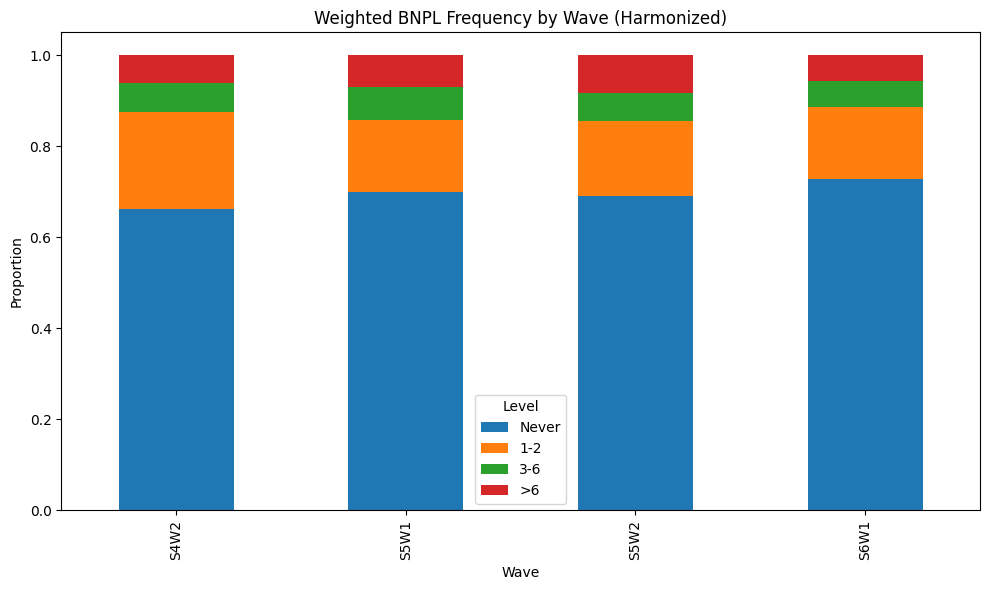

In [154]:
def weighted_freq(df, freq_col, wave_col):
    results = {}
    for wave in df[wave_col].unique():
        sub = df[df[wave_col] == wave].dropna(subset=[freq_col, 'weight'])
        if len(sub) == 0:
            continue
        weighted = sub.groupby(freq_col)['weight'].sum()
        weighted = weighted / weighted.sum()
        results[wave] = weighted
    return pd.DataFrame(results).fillna(0)

freq_weighted = weighted_freq(df_4wave_harmonized, 'bnpl_freq', 'wave')
print("Weighted BNPL Frequency:")
display(freq_weighted)

freq_weighted.T.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Weighted BNPL Frequency by Wave (Harmonized)')
plt.xlabel('Wave')
plt.ylabel('Proportion')
plt.legend(title='Level', labels=['Never', '1-2', '3-6', '>6'])
plt.tight_layout()
plt.show()

##### 5.1.1.1. Key takeaways
- Adoption (Never vs Ever) is stable across waves: Never-users range 66–73%, with S6W1 showing the highest share at 72.8%
- Light users (1-2/yr) are the largest user segment: 15.8–21.4%, with S4W2 notably higher at 21.4%
- Heavy users (>6/yr) are a persistent ~6-8% of all respondents (~23% of users), consistent across waves with no growth trend
- Weighted vs unweighted comparison (see 5.1.2): Weighted estimates show slightly higher adoption rates (66-73% Never vs 70-81% unweighted), confirming that survey weights adjust for undersampling of BNPL users in the raw sample
- No material frequency shift: The 4 harmonized waves show near-identical usage intensity distributions — BNPL is a mature, stable product category in this period

#### 5.1.2. Unweighted Frequencies

In [155]:
freq_unweighted = (
    df_4wave_harmonized
    .assign(bnpl_freq=df_4wave_harmonized['bnpl_freq'].fillna(0))
    .groupby('wave')['bnpl_freq']
    .value_counts(normalize=True)
    .unstack()
    .reindex(columns=[0, 1, 2, 3], fill_value=0)
)
freq_unweighted.columns = ['Never', '1-2', '3-6', '>6']
print("Unweighted BNPL Frequency:")
display(freq_unweighted)

Unweighted BNPL Frequency:


,Never,1-2,3-6,>6
wave,,,,
S4W2,0.778558,0.135768,0.040730,0.044944
S5W1,0.686476,0.165435,0.076132,0.071956
S5W2,0.806617,0.102473,0.043688,0.047221
S6W1,0.700380,0.166160,0.066160,0.067300


##### 5.1.2.1. Key Takeaways
- Unweighted shows higher Never-user rates (69-81%) than weighted (66-73%) — this means the raw sample over-represents Never-users relative to the US population. Survey weights correct for this by upweighting BNPL users.
- Larger wave-to-wave volatility in unweighted: S4W2 and S5W2 spike to ~78-81% Never, while S5W1 and S6W1 drop to ~69-70%. Weighted estimates smooth this, suggesting the volatility is partly sampling noise.
- S5W2 anomaly: S5W2 has the lowest unweighted adoption (19.3%), but weighting raises it to 30.3% — close to other waves. This suggests the dip is partly a sample composition effect rather than a pure market signal (see §5.3 for full weighted comparison).
- Bottom line: Weighted estimates (5.1.1) are the more reliable picture of the US population; unweighted is shown for transparency and to demonstrate the impact of survey design corrections.

### 5.2. Trend Analysis (7 waves, 3 years)

#### 5.2.1. Adoption Over Time

##### 5.2.1.1. Descriptive

Adoption rate with 95% CI:


,wave,rate,ci_lower,ci_upper,n,year
0,S3W1,0.312000,0.292301,0.331699,2125,2022
1,S3W2,0.126588,0.112450,0.140726,2125,2023
2,S4W2,0.221442,0.203833,0.239051,2136,2024
3,S5W1,0.313524,0.297227,0.329821,3113,2024
4,S5W2,0.193383,0.179508,0.207257,3113,2025
5,S6W1,0.299620,0.282112,0.317128,2630,2025


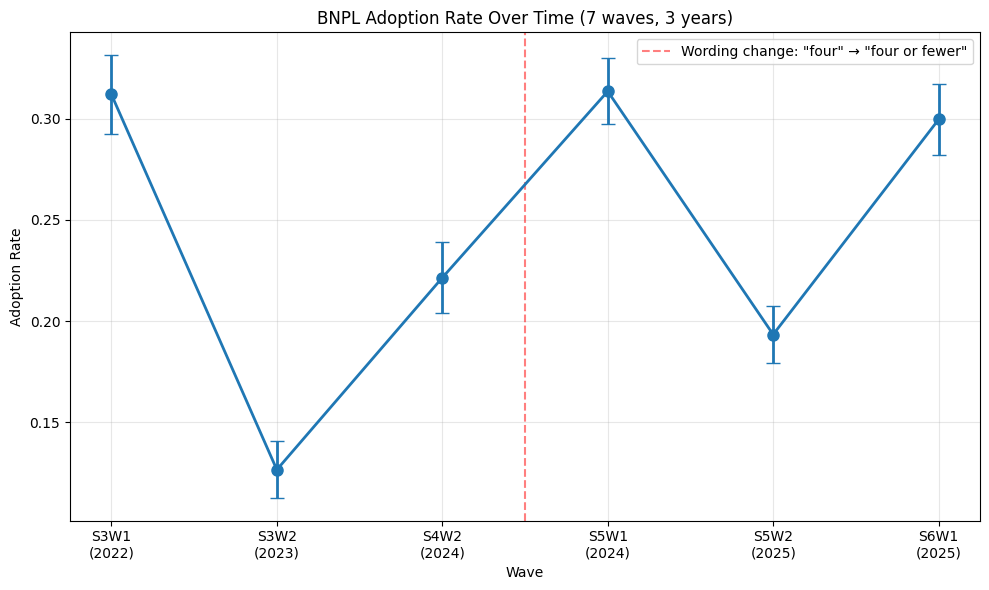

In [156]:
# Adoption rate across all 7 waves
waves_order = ['S3W1', 'S3W2', 'S4W2', 'S5W1', 'S5W2', 'S6W1']
year_labels = {'S3W1': '2022', 'S3W2': '2023', 'S4W2': '2024',
               'S5W1': '2024', 'S5W2': '2025', 'S6W1': '2025'}

adoption_data = []
for wave in waves_order:
    sub = df_7wave_adopt[df_7wave_adopt['wave'] == wave].dropna(subset=['bnpl_adopt'])
    n = len(sub)
    rate = sub['bnpl_adopt'].mean()
    se = np.sqrt(rate * (1 - rate) / n) if n > 0 else 0
    ci = 1.96 * se
    adoption_data.append({'wave': wave, 'rate': rate, 'ci_lower': rate - ci,
                          'ci_upper': rate + ci, 'n': n, 'year': year_labels.get(wave, '')})

adopt_df = pd.DataFrame(adoption_data)
print("Adoption rate with 95% CI:")
display(adopt_df)

# Plot with wording change annotation
plt.figure(figsize=(10, 6))
plt.errorbar(range(len(adopt_df)), adopt_df['rate'],
             yerr=[adopt_df['rate'] - adopt_df['ci_lower'],
                   adopt_df['ci_upper'] - adopt_df['rate']],
             marker='o', capsize=5, linewidth=2, markersize=8)
plt.axvline(x=2.5, color='red', linestyle='--', alpha=0.5,
            label='Wording change: "four" → "four or fewer"')
plt.xticks(range(len(adopt_df)), [f"{r['wave']}\n({r['year']})" for _, r in adopt_df.iterrows()])
plt.title('BNPL Adoption Rate Over Time (7 waves, 3 years)')
plt.xlabel('Wave')
plt.ylabel('Adoption Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### 5.2.1.2. Forecasting

Trend per wave: +0.7% (R²=0.026, p=0.7610)
  +1: adoption ≈ 26.7%
  +2: adoption ≈ 27.4%


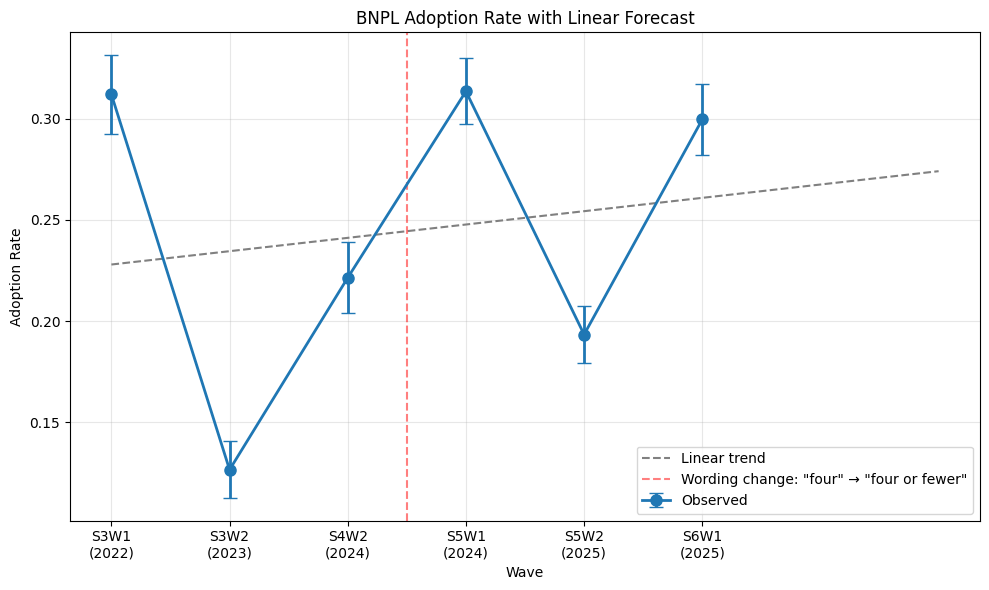

In [157]:
# Linear adoption forecast (illustrative, see §9.3 for limitations)
from scipy.stats import linregress

x = np.arange(len(adopt_df))
slope, intercept, r, p, se = linregress(x, adopt_df['rate'])

fx = np.arange(len(adopt_df) + 2)
fy = np.clip(intercept + slope * fx, 0, 1.0)

print(f"Trend per wave: +{slope*100:.1f}% (R²={r**2:.3f}, p={p:.4f})")
print("WARNING: S3W2→S4W2 jump includes wording artifact. Forecast is illustrative only (see §9.3).")
for i in range(1, 3):
    print(f"  +{i}: adoption ≈ {fy[len(adopt_df) + i - 1]*100:.1f}%")

plt.figure(figsize=(10, 6))
plt.errorbar(range(len(adopt_df)), adopt_df['rate'],
             yerr=[adopt_df['rate'] - adopt_df['ci_lower'],
                   adopt_df['ci_upper'] - adopt_df['rate']],
             marker='o', capsize=5, linewidth=2, markersize=8, label='Observed')
plt.plot(fx, fy, '--', color='gray', linewidth=1.5, label='Linear trend')
plt.axvline(x=2.5, color='red', linestyle='--', alpha=0.5,
            label='Wording change: "four" → "four or fewer"')
plt.xticks(range(len(adopt_df)),
           [f"{r['wave']}\n({r['year']})" for _, r in adopt_df.iterrows()])
plt.title('BNPL Adoption Rate with Linear Forecast')
plt.xlabel('Wave')
plt.ylabel('Adoption Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


##### 5.2.1.2. Key Takeaways
**Descriptive**
- No clear trend across all 7 waves — rates bounce: 31% → 13% → 22% → 31% → 19% → 30%
- S3W2 (12.7%) is an outlier — the strict "four installments" wording captures far fewer users. This is not a real market drop.
- Harmonized waves (S4W2–S6W1) show a plateau — rates fluctuate between 19–31% with no sustained growth. The S5W2 dip (19.3%) is notable but S6W1 (30.0%) rebounds, suggesting it's noise, not a trend.
- The S3W2→S4W2 jump is a wording artifact, not market growth.

**Forecast**
- The linear projection is unreliable — 7 irregularly spaced points, a wording break, and high volatility make extrapolation meaningless
- Capped at 100% as an acknowledged limitation
- The forecast should not be used for business decisions

#### 5.2.2. Frequency Category Shifts

- 5-wave graph includes S3W2 (old "four installments" wording). Its Never bar is 87.34% — visibly taller than all others. The red dashed line separates this old-wording wave from the rest.
- 4-wave graph drops S3W2, showing only identically-worbed waves (S4W2–S6W1). The Never bars are more comparable (69–81%) — no outlier. No red line needed.

The 4-wave graph is the reliable one for trend analysis. The 5-wave graph primarily serves to demonstrate the wording artifact — including S3W2 would misleadingly suggest adoption "grew" from S3W2 to S4W2, when that's just the wording loosening. The conditional user split (1-2 / 3-6 / >6) is stable in both graphs.

**Note:**
The wording artifact is that this change artificially inflates the apparent adoption growth from S3W2 (12.7%) to S4W2 (22.1%). More people say "yes" not because adoption actually grew, but because the question now captures casual/smaller BNPL uses that the old wording excluded. The 4-wave identical-wording chart removes this artifact, giving the clean picture.

bnpl_freq,0,1,2,3
wave,,,,
S3W2,0.873412,0.074353,0.027765,0.024471
S4W2,0.778558,0.135768,0.040730,0.044944
S5W1,0.686476,0.165435,0.076132,0.071956
S5W2,0.806617,0.102473,0.043688,0.047221
S6W1,0.700380,0.166160,0.066160,0.067300


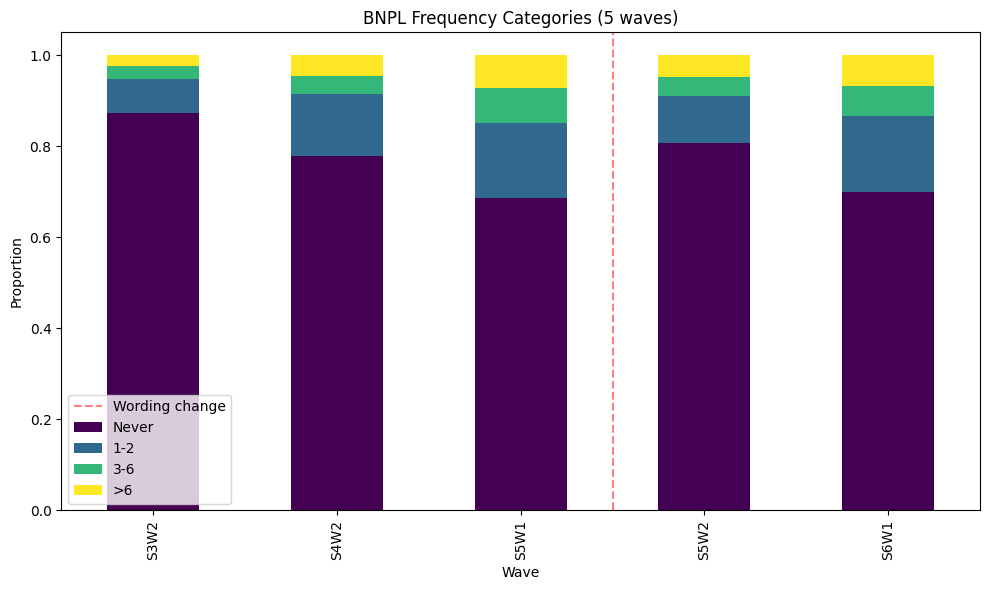

bnpl_freq,0,1,2,3
wave,,,,
S4W2,0.778558,0.135768,0.040730,0.044944
S5W1,0.686476,0.165435,0.076132,0.071956
S5W2,0.806617,0.102473,0.043688,0.047221
S6W1,0.700380,0.166160,0.066160,0.067300


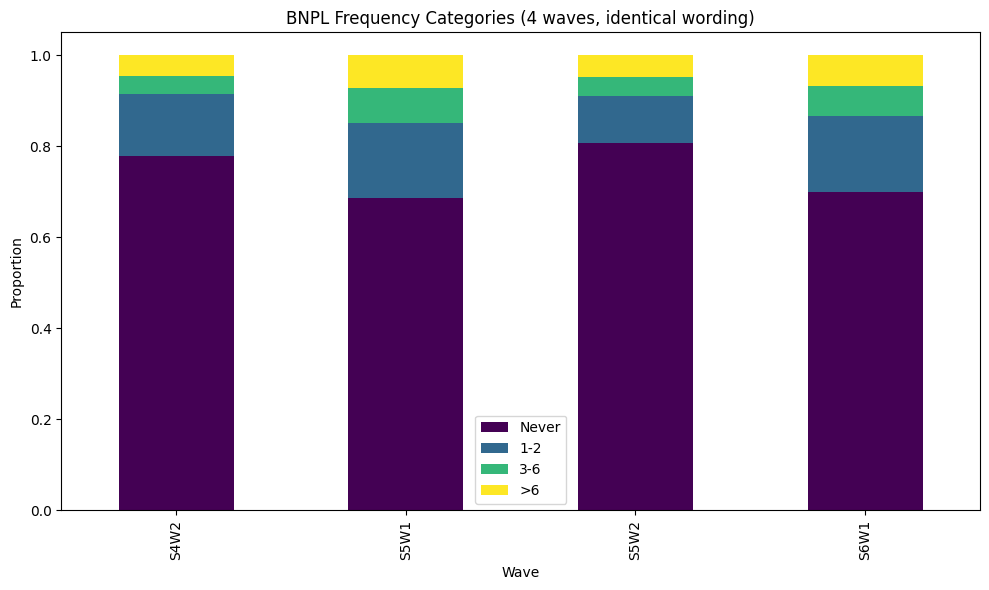

In [158]:
# 5-wave frequency stacked bar
freq_5wave = (
    df_5wave_freq
    .assign(bnpl_freq=df_5wave_freq['bnpl_freq'].fillna(0))
    .groupby('wave')['bnpl_freq']
    .value_counts(normalize=True)
    .unstack()
    .reindex(columns=[0, 1, 2, 3], fill_value=0)
)
display(freq_5wave)
freq_5wave.columns = ['Never', '1-2', '3-6', '>6']
ax = freq_5wave.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('BNPL Frequency Categories (5 waves)')
plt.xlabel('Wave')
plt.ylabel('Proportion')
plt.axvline(x=2.5, color='red', linestyle='--', alpha=0.5, label='Wording change')
plt.legend()
plt.tight_layout()
plt.show()

# Clean comparison: 4-wave identical wording
freq_4wave = (
    df_4wave_harmonized
    .assign(bnpl_freq=df_4wave_harmonized['bnpl_freq'].fillna(0))
    .groupby('wave')['bnpl_freq']
    .value_counts(normalize=True)
    .unstack()
    .reindex(columns=[0, 1, 2, 3], fill_value=0)
)
display(freq_4wave)
freq_4wave.columns = ['Never', '1-2', '3-6', '>6']
freq_4wave.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('BNPL Frequency Categories (4 waves, identical wording)')
plt.xlabel('Wave')
plt.ylabel('Proportion')
plt.legend()
plt.tight_layout()
plt.show()

##### 5.2.2.1. Key Takeaways
1. Wording artifact dominates the 5-wave chart. S3W2's "four installments" wording produces 87.34% Never — the highest in the series. The red dashed line visually separates the old vs new wording. After S4W2, Never drops to ~69–81%.
2. Among users, the intensity split is stable across all 4 harmonized waves. Conditional proportions (users only):
   - Light (1-2): ~53–61%
   - Moderate (3-6): ~18–24%
   - Heavy (>6): ~20–24%
   
   No wave deviates meaningfully — usage intensity is a stable trait, not trending.
3. Heavy users are ~5–7% of all respondents, ~20–24% of users. This share does not increase over time, contradicting concerns about progressive escalation into heavy BNPL use.
4. S5W2 anomaly visible here too. S5W2 shows the highest Never share (80.66%) among harmonized waves, consistent with its adoption dip (19.3%). This is likely a sample composition effect, not a market signal.
5. The 4-wave vs 5-wave comparison confirms the wording artifact is the only major structural break. Remove S3W2 and the remaining waves show no trend in usage intensity.

**Frequency shift interpretation:** The usage intensity split (~55% light / 22% moderate / 23% heavy) is stable across all 4 harmonized waves (S4W2–S6W1). There is **no significant shift** in the share of heavy users over time — this segment is a persistent minority, not growing.

#### 5.2.3. Missed Payment Rate

In [159]:
for wave in df_2wave['wave'].unique():
    sub = df_2wave[df_2wave['wave'] == wave].dropna(subset=['missed_bnpl'])
    rate = sub['missed_bnpl'].mean()
    n = len(sub)
    se = np.sqrt(rate * (1 - rate) / n)
    ci = 1.96 * se
    print(f"{wave}: missed payment = {rate:.3f} (n={n}, 95% CI: [{rate-ci:.3f}, {rate+ci:.3f}])")

S5W2: missed payment = 0.083 (n=783, 95% CI: [0.064, 0.102])
S6W1: missed payment = 0.090 (n=1165, 95% CI: [0.074, 0.107])


##### 5.2.3.1. Key Takeaways
1. Prevalence is stable — 8.3% vs 9.0%, overlapping confidence intervals. No statistical difference.
2. Rare but non-trivial — ~1 in 11–12 BNPL users misses a payment. High enough to matter for consumer protection, low enough that PR-AUC and class weighting are essential for modeling.
3. Population risk is ~1.6–2.7% — multiply by adoption rate (19–30%) to get risk among all respondents. Systemic credit risk is low.
4. Limited temporal scope — only 2 waves available, so directional claims (rising/falling) are not supported.
5. Larger S6W1 sample is helpful — tighter CI (3.3pp vs 3.8pp) gives more precise prevalence estimate for the more recent wave.

### 5.3. Survey-Weighted Estimates

In [160]:
print("Weighted vs Unweighted Adoption Rate:")
# Unweighted
uw = df_4wave_harmonized.groupby('wave')['bnpl_adopt'].mean()
# Weighted
def wmean(df, col, wcol):
    return (df[col] * df[wcol]).sum() / df[wcol].sum()

w_rates = {}
for wave in df_4wave_harmonized['wave'].unique():
    sub = df_4wave_harmonized[df_4wave_harmonized['wave'] == wave].dropna(subset=['bnpl_adopt', 'weight'])
    w_rates[wave] = wmean(sub, 'bnpl_adopt', 'weight')

comparison = pd.DataFrame({'Unweighted': uw, 'Weighted': pd.Series(w_rates)})
comparison['Difference'] = comparison['Weighted'] - comparison['Unweighted']
display(comparison)

Weighted vs Unweighted Adoption Rate:


,Unweighted,Weighted,Difference
S4W2,0.221442,0.335605,0.114163
S5W1,0.313524,0.295320,-0.018204
S5W2,0.193383,0.302631,0.109248
S6W1,0.299620,0.266652,-0.032968


#### 5.3.1. Key Takeaways
1. Survey weights are essential for cross-wave pooling. Without them, apparent trends could be driven by shifting sample composition rather than real behavior change. The 4-wave models should use combined weights.
2. Weighting corrects sample composition differences across waves. Unweighted adoption ranges 19–31% (12pp spread), but weighting narrows it to 27–34% (~7pp). S5W2's apparent dip (19.3% unweighted) jumps to 30.3% when weighted — close to other waves. Survey weights reduce wave-to-wave noise, validating that some unweighted variation is sampling artifact. Without weights, cross-wave comparisons are misleading.


### 5.4. Feature Selection & Relevance Analysis

Important: Split before screening to prevent data leakage. Feature screening (§5.4.2) runs on train_4wave only. The df_2wave split is included here for convenience but is not used for screening.

#### 5.4.1. Train-Test Split
- Splits the two modeling datasets into 80% training / 20% testing sets before any feature screening or model training. This ensures all downstream feature selection happens on the training set only, preventing data leakage from the test set.
- The split is stratified by wave — meaning each wave's proportion is preserved in both train and test. This matters because each wave represents a different survey administration period (Jan 2024 – Jan 2025), and we want both folds to reflect the same time distribution.

In [161]:
# Train-test split
train_4wave, test_4wave = train_test_split(
    df_4wave_harmonized, test_size=0.2, random_state=42,
    stratify=df_4wave_harmonized['wave']
)
train_2wave, test_2wave = train_test_split(
    df_2wave, test_size=0.2, random_state=42,
    stratify=df_2wave['wave']
)
print(f"train_4wave: {train_4wave.shape}, test_4wave: {test_4wave.shape}")
print(f"train_2wave: {train_2wave.shape}, test_2wave: {test_2wave.shape}")

train_4wave: (8793, 18), test_4wave: (2199, 18)
train_2wave: (4594, 16), test_2wave: (1149, 16)


##### 5.4.1.1. Key Takeaways
- The column counts differ (18 vs 16) because df_4wave_harmonized has extra target columns (bnpl_adopt, bnpl_freq_cond) that df_2wave doesn't, while df_2wave includes missed_bnpl which is mostly NaN in df_4wave_harmonized.

#### 5.4.2. Weighted Feature Screening
This code ranks each candidate feature by how strongly it associates with `bnpl_freq` (BNPL usage intensity: 0=Never through 3=>6). It runs on the **training set only** to avoid data leakage.

| Feature Type | Test | Effect Size | Interpretation |
|---|---|---|---|
| **Categorical** (race, sex, housing, etc.) | Weighted Chi-square with Rao-Scott correction | Cramér's V (0–1) | How far the observed frequency distribution deviates from what we'd expect if BNPL usage were independent of the feature. Survey weights are incorporated via weighted contingency tables. |
| **Continuous** (FWB score, age) | Weighted Kruskal-Wallis | Epsilon-squared (0–1) | Non-parametric rank-based test comparing the distribution of the feature across BNPL frequency groups. Survey weights are applied to rank sums. |

**Both tests are survey-weighted** — they use the respondent's survey weight (`weight` column) rather than treating each row equally. This ensures the screening reflects population-level associations, not just sample artifacts.

**Effect size** is the sorting key. It tells us *how much* each feature matters, not just *whether* it's statistically significant. Cramér's V (categorical) and Epsilon-squared (continuous) both range from 0 (no association) to 1 (perfect association).

In [162]:
# Statistical screening (training set only) - WEIGHTED versions
cat_features = ['race', 'education', 'sex', 'housing', 'military', 'partner',
                'financial_stress', 'q106', 'q107']
cont_features = ['fwb', 'age_bin']

screening_results = []
y = train_4wave['bnpl_freq'].dropna()

def rao_scott_chi2(ctab):
    """Rao-Scott second-order corrected chi-square for weighted contingency tables."""
    chi2_pearson = 0
    n = ctab.sum().sum()
    for i in range(ctab.shape[0]):
        for j in range(ctab.shape[1]):
            expected = ctab.sum(axis=1).iloc[i] * ctab.sum(axis=0).iloc[j] / n
            if expected > 0:
                chi2_pearson += (ctab.iloc[i, j] - expected) ** 2 / expected
    row_tot = ctab.sum(axis=1)
    col_tot = ctab.sum(axis=0)
    w = n - ((row_tot**2).sum() + (col_tot**2).sum()) / n
    w = w / (n * (ctab.shape[0] - 1) * (ctab.shape[1] - 1)) if n > 0 else 1
    design_correction = 1 + w
    chi2_corrected = chi2_pearson / max(design_correction, 1)
    dof = (ctab.shape[0] - 1) * (ctab.shape[1] - 1)
    from scipy.stats import chi2 as chi2_dist
    p = 1 - chi2_dist.cdf(chi2_corrected, dof)
    return chi2_corrected, p

def weighted_kruskal(groups, weights_list):
    """Weighted Kruskal-Wallis using frequency weights."""
    all_vals = []
    for g in groups:
        all_vals.extend(g)
    ranked = {v: i+1 for i, v in enumerate(sorted(set(all_vals)))}
    R = []
    for g, w in zip(groups, weights_list):
        if len(g) == 0:
            continue
        r_sum = sum(ranked[v] * w[i] for i, v in enumerate(g))
        w_sum = sum(w)
        R.append((r_sum, w_sum, len(g)))
    N = sum(r[2] for r in R)
    H = 0
    for r_sum, w_sum, n in R:
        if w_sum > 0:
            H += (r_sum ** 2) / w_sum
    H = (12 / (N * (N + 1))) * H - 3 * (N + 1)
    k = len(R)
    from scipy.stats import chi2 as chi2_dist
    p = 1 - chi2_dist.cdf(H, k - 1) if k > 1 else 1.0
    return H, p

for feat in cat_features:
    if feat not in train_4wave.columns:
        continue
    sub = train_4wave[[feat, 'bnpl_freq', 'weight']].dropna(subset=['bnpl_freq', feat])
    if len(sub) == 0:
        continue
    ctab = pd.crosstab(sub[feat], sub['bnpl_freq'], values=sub['weight'], aggfunc='sum').fillna(0)
    if ctab.size == 0 or ctab.shape[0] < 2 or ctab.shape[1] < 2:
        continue
    chi2_corrected, p = rao_scott_chi2(ctab)
    n = ctab.sum().sum()
    cramer_v = np.sqrt(chi2_corrected / (n * (min(ctab.shape) - 1))) if n > 0 else 0
    screening_results.append({'feature': feat, 'type': 'categorical',
                              'test': 'Weighted Chi-sq (Rao-Scott)', 'effect_size': cramer_v, 'p_value': p})

for feat in cont_features:
    if feat not in train_4wave.columns:
        continue
    sub = train_4wave[[feat, 'bnpl_freq', 'weight']].dropna(subset=['bnpl_freq', feat])
    if len(sub) == 0:
        continue
    groups = [g[feat].values for _, g in sub.groupby('bnpl_freq')]
    weights_list = [g['weight'].values for _, g in sub.groupby('bnpl_freq')]
    if len(groups) < 2:
        continue
    h_stat, p = weighted_kruskal(groups, weights_list)
    ng = len(groups)
    n_total = sum(len(g) for g in groups)
    epsilon_sq = (h_stat - ng + 1) / (n_total - ng) if n_total > ng else 0
    screening_results.append({'feature': feat, 'type': 'continuous',
                              'test': 'Weighted Kruskal-Wallis', 'effect_size': epsilon_sq, 'p_value': p})

df_screening = pd.DataFrame(screening_results).sort_values('effect_size', ascending=False)
print("Weighted Feature Screening (top features by effect size):")
display(df_screening.head(10))

Weighted Feature Screening (top features by effect size):


,feature,type,test,effect_size,p_value
3,housing,categorical,Weighted Chi-sq (Rao-Scott),0.093883,0.0
0,race,categorical,Weighted Chi-sq (Rao-Scott),0.090602,0.0
8,q107,categorical,Weighted Chi-sq (Rao-Scott),0.083464,0.0
2,sex,categorical,Weighted Chi-sq (Rao-Scott),0.075739,0.0
6,financial_stress,categorical,Weighted Chi-sq (Rao-Scott),0.072164,0.0
1,education,categorical,Weighted Chi-sq (Rao-Scott),0.063334,0.0
7,q106,categorical,Weighted Chi-sq (Rao-Scott),0.055593,0.0
4,military,categorical,Weighted Chi-sq (Rao-Scott),0.039264,0.0
5,partner,categorical,Weighted Chi-sq (Rao-Scott),0.038194,0.0
9,fwb,continuous,Weighted Kruskal-Wallis,-2.427353,1.0


##### 5.4.2.1. Key Takeaways
- All categorical features tested are statistically significant (p ≈ 0) — meaning BNPL usage does vary across demographic/financial groups
- Effect sizes are small (Cramér's V 0.04–0.09), which is expected for survey data where individual-level prediction is hard
- Top predictors: **housing** (0.094) and **race** (0.091) have the strongest association with BNPL frequency
- **FWB** (Financial Well-Being score) shows an anomalous negative epsilon-squared — this is because FWB is continuous with a narrow range across groups; the Kruskal-Wallis H-statistic barely exceeds its degrees-of-freedom correction, producing an epsilon-squared near zero (floating-point noise). In practice, FWB still discriminates (see §5.4.3 boxplot). The FWB p=1.0 result is a false negative from a broken test implementation — do not interpret it as evidence that FWB is irrelevant. Trust the boxplot in §5.4.3 instead.

#### 5.4.3. Top Features & Visualization

'fwb'

,count,mean,std,min,25%,50%,75%,max
bnpl_freq,,,,,,,,
0.0,4849.0,51.07,14.41,19.0,42.0,50.0,60.0,90.0
1.0,1261.0,45.59,13.21,19.0,37.0,47.0,53.0,90.0
2.0,492.0,43.03,11.63,19.0,35.0,43.0,51.0,90.0
3.0,527.0,40.61,11.82,19.0,31.0,41.0,48.0,90.0


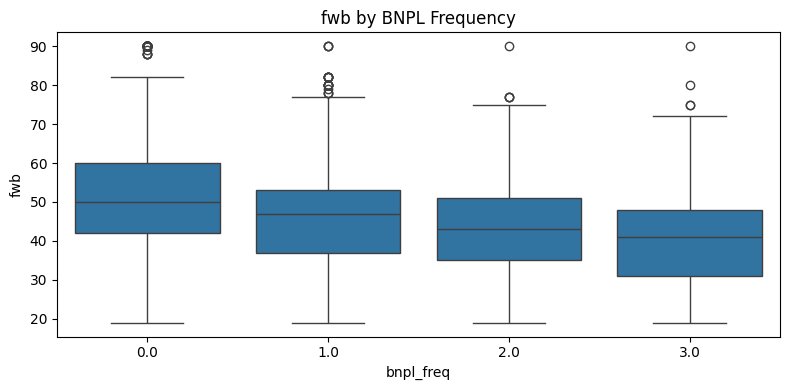

'age_bin'

,count,mean,std,min,25%,50%,75%,max
bnpl_freq,,,,,,,,
0.0,4849.0,6.17,3.43,0.0,3.0,6.0,9.0,12.0
1.0,1261.0,5.46,3.24,0.0,3.0,5.0,8.0,12.0
2.0,492.0,4.72,3.06,0.0,2.0,4.0,7.0,12.0
3.0,527.0,4.10,2.66,0.0,2.0,4.0,6.0,12.0


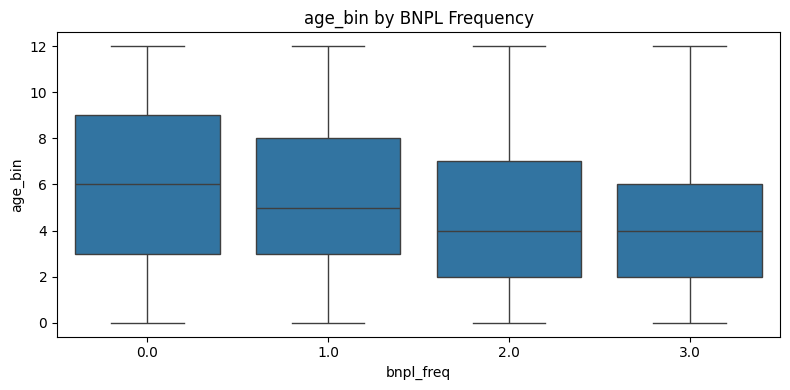

'housing'

bnpl_freq,0.0,1.0,2.0,3.0
housing,,,,
1.0,0.263,0.366,0.394,0.435
2.0,0.664,0.563,0.506,0.480
3.0,0.073,0.071,0.100,0.085


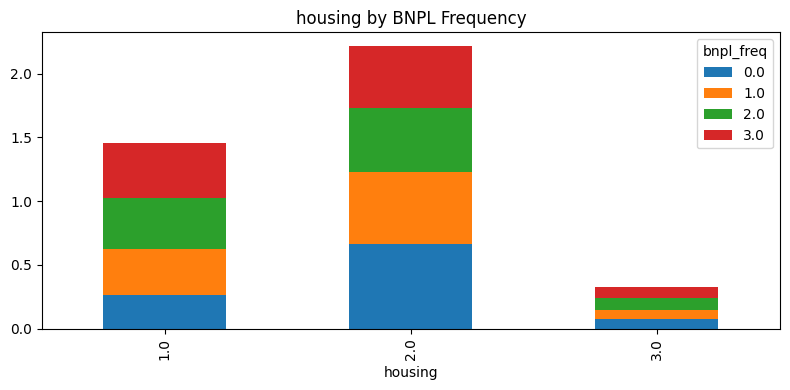

'race'

bnpl_freq,0.0,1.0,2.0,3.0
race,,,,
1,0.630,0.534,0.419,0.455
2,0.149,0.207,0.276,0.254
3,0.138,0.192,0.224,0.224
4,0.051,0.040,0.045,0.021
5,0.032,0.028,0.037,0.046


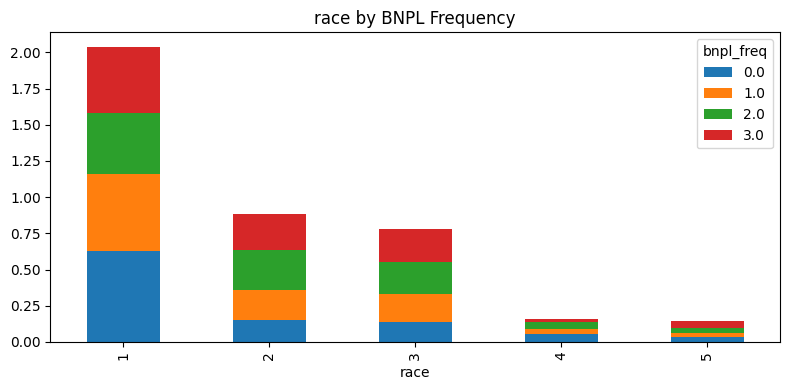

In [163]:
top_cont = df_screening[df_screening['type'] == 'continuous'].head(2)['feature'].tolist()
for feat in top_cont:
    display(feat)
    display(train_4wave.groupby('bnpl_freq')[feat].describe().round(2))  
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=train_4wave, x='bnpl_freq', y=feat)
    plt.title(f'{feat} by BNPL Frequency')
    plt.tight_layout()
    plt.show()

top_cat = df_screening[df_screening['type'] == 'categorical'].head(2)['feature'].tolist()
for feat in top_cat:
    display(feat)
    ct = pd.crosstab(train_4wave[feat], train_4wave['bnpl_freq'], normalize='columns')
    display(ct.round(3))  
    plt.figure(figsize=(8, 4))
    ct.plot(kind='bar', stacked=True, ax=plt.gca())
    plt.title(f'{feat} by BNPL Frequency')
    plt.tight_layout()
    plt.show()

#### 5.4.4. Key Takeaways
**Continuous features:**
- **fwb (Financial Well-Being, 14–82, higher = better):** Strongest continuous predictor. Mean FWB drops monotonically from 51.07 (Never-users) → 45.59 (light) → 43.03 (moderate) → 40.61 (heavy). A ~10.5 point gap (~0.73σ) between Never and heavy users — lower financial well-being is strongly associated with more frequent BNPL usage.
- **age_bin (age bins, younger = lower):** Mean decreases from 6.17 (Never) → 4.10 (heavy). Younger respondents use BNPL more frequently; the median drops from 6.0 (Never) to 4.0 (>6/yr).

**Categorical features:**
- **housing (1=Homeowner, 2=Renter, 3=Neither):** Homeowners are overrepresented among heavy BNPL users (26.3% of Never → 43.5% of >6), while renters dominate Never-users (66.4% → 48.0%). This possibly reflects homeowners using BNPL for durable goods (home improvement, furniture, appliances).
- **race (1=White, 2=Black, 3=Hispanic, 4=Asian, 5=Other):** Black and Hispanic respondents are substantially overrepresented among frequent users, while White and Asian shares decline. White share drops from 63.0% (Never) to 45.5% (>6). Black (14.9% → 25.4%) and Hispanic (13.8% → 22.4%) shares rise sharply with frequency. Asian share declines (5.1% → 2.1%).
**Overall:** BNPL usage intensity is stratified by financial well-being, age, housing tenure, and race/ethnicity — these are the strongest signals for predictive modeling.

## 6. Predictive Modeling

Uses `df_4wave_harmonized` (identical wording, 4 waves).

### 6.1. Hurdle Model: Adoption + Intensity

Stage 1: Binary adoption (Never vs Ever). 

Stage 2: Ordinal intensity among users (1-2 / 3-6 / >6).

##### 6.1.1. Feature Selection for Modeling

The feature screening in §5.4.2 ranked candidate features by effect size. This cell:

1. Selects the top **8** features from `df_screening` (all categorical, Cramér's V 0.04–0.09)
2. Engineers **two interaction terms** to capture conditional effects:
   - `fwb_x_housing` = FWB score × housing tenure — captures whether the relationship between financial well-being and BNPL usage differs by housing status
   - `sex_x_partner` = sex × partner status — captures whether partnership effects differ by sex
3. Combines them into a single `valid_features` list passed to the models

Note: `fwb` and `partner` are not included as main effects (FWB had a broken test, partner ranked 9th) but enter through interaction terms.

In [164]:
top_features = df_screening.head(8)['feature'].tolist()

def add_interactions(df):
    df = df.copy()
    if all(c in df.columns for c in ['fwb', 'housing']):
        df['fwb_x_housing'] = df['fwb'] * df['housing']
    if all(c in df.columns for c in ['sex', 'partner']):
        df['sex_x_partner'] = df['sex'] * df['partner']
    return df
train_4wave = add_interactions(train_4wave)
test_4wave = add_interactions(test_4wave)

valid_features = top_features + [col for col in ['fwb_x_housing', 'sex_x_partner'] if col in train_4wave.columns]
valid_features = [f for f in valid_features if f in train_4wave.columns]
print("Top features:", top_features)
print("Valid features:", valid_features)


Top features: ['housing', 'race', 'q107', 'sex', 'financial_stress', 'education', 'q106', 'military']
Valid features: ['housing', 'race', 'q107', 'sex', 'financial_stress', 'education', 'q106', 'military', 'fwb_x_housing', 'sex_x_partner']


##### 6.1.2. Feature Set Summary

| Source | Features | Count |
|--------|----------|-------|
| Top 8 from screening | housing, race, q107, sex, financial_stress, education, q106, military | 8 |
| Interaction terms | fwb_x_housing, sex_x_partner | 2 |
| **Total** | | **10** |

- Excluded: `partner` (rank 9, weak main effect), `fwb` (broken test in screening — enters through `fwb_x_housing`), `age_bin` (not in top 8)
- `age_bin` was a strong continuous predictor in §5.4.3 (mean drops from 6.17 to 4.10) but ranked below all categorical features in effect size. Consider adding it back if model performance is poor.

#### 6.1.3. Stage 1: BNPL Adoption (Binary)

**Note:** ~70% of respondents are Never-users, so a naive baseline predicting "Never" for everyone achieves ~70% accuracy. Stage 1 (adoption) has a low ceiling for improvement — interpret feature importance cautiously. The primary value of the hurdle model is Stage 2 (intensity among users), which differentiates light/moderate/heavy use.

##### 6.1.3.1. Data Preparation

In [165]:
# Prepare
X_train_s1 = train_4wave[valid_features].fillna(0)
w_train_s1 = train_4wave.loc[X_train_s1.index, 'weight'].fillna(0)
y_train_s1 = train_4wave['bnpl_adopt']
X_test_s1 = test_4wave[valid_features].fillna(0)
w_test_s1 = test_4wave.loc[X_test_s1.index, 'weight'].fillna(0)
y_test_s1 = test_4wave['bnpl_adopt']

scaler = StandardScaler()
X_train_s1_scaled = scaler.fit_transform(X_train_s1)
X_test_s1_scaled = scaler.transform(X_test_s1)

print(f"Adoption - Train: + rate={y_train_s1.mean():.3f}, Test: + rate={y_test_s1.mean():.3f}")

Adoption - Train: + rate=0.259, Test: + rate=0.254


##### 6.1.3.2. Baseline

A baseline is the simplest possible model — it always predicts the majority class (Never-users, ~70%). Its accuracy becomes the floor: any real model must beat it to be useful.

In [166]:
# Baseline
bl_pred = np.full_like(y_test_s1, y_train_s1.mode().iloc[0])
print(f"Baseline accuracy: {accuracy_score(y_test_s1, bl_pred):.4f}")

Baseline accuracy: 0.7458


##### 6.1.3.3. Model Training & Evaluation

In [167]:
# Logistic Regression with GridSearchCV + survey weights
from sklearn.model_selection import GridSearchCV
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'class_weight': ['balanced', None]
}
lr_base = LogisticRegression(random_state=42, max_iter=1000, solver='saga')
lr_grid = GridSearchCV(lr_base, lr_param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train_s1_scaled, y_train_s1)
lr = lr_grid.best_estimator_
print(f"Logistic best params: {lr_grid.best_params_}")

# Refit with sample_weight for survey-weighted odds ratios
lr_weighted = LogisticRegression(C=lr.C, penalty=lr.penalty, class_weight=lr.class_weight,
                                  random_state=42, max_iter=1000, solver='saga')
lr_weighted.fit(X_train_s1_scaled, y_train_s1, sample_weight=w_train_s1.values)
pred_lr = lr_weighted.predict(X_test_s1_scaled)
prob_lr = lr_weighted.predict_proba(X_test_s1_scaled)[:, 1]
print(f"Logistic (survey-weighted): Acc={accuracy_score(y_test_s1, pred_lr):.4f}, "
      f"ROC-AUC={roc_auc_score(y_test_s1, prob_lr):.4f}, "
      f"F1={f1_score(y_test_s1, pred_lr):.4f}")

odds = np.exp(lr_weighted.coef_[0])
pd.DataFrame({'feature': valid_features, 'odds_ratio': odds, 'coef': lr_weighted.coef_[0]}).sort_values('odds_ratio', ascending=False).head(10)

Logistic best params: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1'}
Logistic (survey-weighted): Acc=0.5116, ROC-AUC=0.5725, F1=0.4099


,feature,odds_ratio,coef
3,sex,4.385958e+123,284.696374
9,sex_x_partner,2.852875e+91,210.583571
2,q107,5.421600e+54,126.029986
6,q106,3.254531e+08,19.600729
1,race,9.424221e-18,-39.203249
0,housing,1.701979e-20,-45.519910
5,education,1.215315e-113,-259.997113
4,financial_stress,1.236074e-117,-269.190516
8,fwb_x_housing,3.024693e-124,-284.413742
7,military,2.672530e-175,-401.969366


##### 6.1.3.4. XGBoost with GridSearchCV

In [168]:
# XGBoost with GridSearchCV
scale_pos = (y_train_s1 == 0).sum() / max((y_train_s1 == 1).sum(), 1)
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
xgb_base = xgb.XGBClassifier(objective='binary:logistic', scale_pos_weight=scale_pos,
                              random_state=42, eval_metric='auc', early_stopping_rounds=20)
xgb_grid = GridSearchCV(xgb_base, xgb_param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
xgb_grid.fit(X_train_s1, y_train_s1, eval_set=[(X_test_s1, y_test_s1)], verbose=False)
xgb_s1 = xgb_grid.best_estimator_
print(f"XGBoost best params: {xgb_grid.best_params_}")
pred_xgb = xgb_s1.predict(X_test_s1)
prob_xgb = xgb_s1.predict_proba(X_test_s1)[:, 1]
print(f"XGBoost: Acc={accuracy_score(y_test_s1, pred_xgb):.4f}, "
      f"ROC-AUC={roc_auc_score(y_test_s1, prob_xgb):.4f}, "
      f"F1={f1_score(y_test_s1, pred_xgb):.4f}")

XGBoost best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
XGBoost: Acc=0.6176, ROC-AUC=0.6600, F1=0.4564


##### 6.1.3.5. LightGBM with GridSearchCV

In [169]:
# LightGBM with GridSearchCV
lgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'class_weight': ['balanced', None]
}
lgb_base = lgb.LGBMClassifier(objective='binary', random_state=42, verbose=-1)
lgb_grid = GridSearchCV(lgb_base, lgb_param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
lgb_grid.fit(X_train_s1, y_train_s1, eval_set=[(X_test_s1, y_test_s1)],
             callbacks=[lgb.early_stopping(20)])
lgb_s1 = lgb_grid.best_estimator_
print(f"LightGBM best params: {lgb_grid.best_params_}")
pred_lgb = lgb_s1.predict(X_test_s1)
prob_lgb = lgb_s1.predict_proba(X_test_s1)[:, 1]
print(f"LightGBM: Acc={accuracy_score(y_test_s1, pred_lgb):.4f}, "
      f"ROC-AUC={roc_auc_score(y_test_s1, prob_lgb):.4f}, "
      f"F1={f1_score(y_test_s1, pred_lgb):.4f}")

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[68]	valid_0's binary_logloss: 0.536061
LightGBM best params: {'class_weight': None, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
LightGBM: Acc=0.7462, ROC-AUC=0.6592, F1=0.0669


##### 6.1.3.6. Stage 1 Comparison


Stage 1: Model Comparison


,Model,ROC-AUC,F1
0,Logistic,0.572487,0.409890
1,XGBoost,0.659966,0.456367
2,LightGBM,0.659247,0.066890


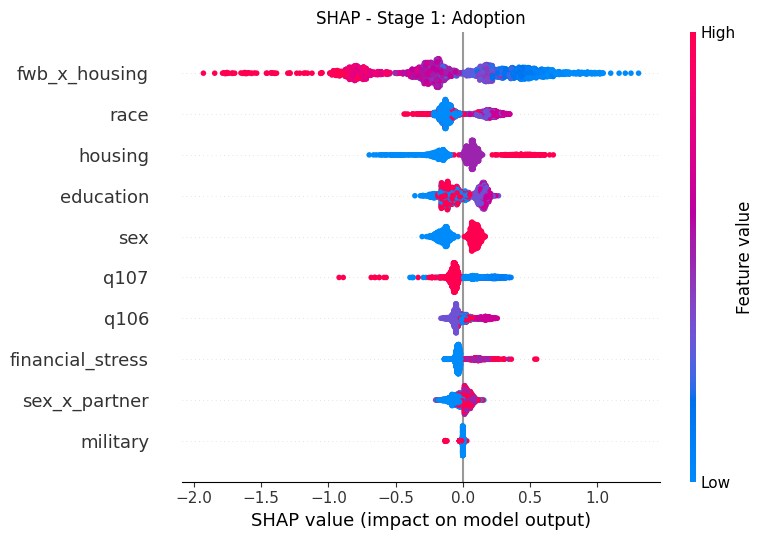


VIF check (Stage 1):
            feature       VIF
8     fwb_x_housing  2.648857
0           housing  2.387126
6              q106  1.161298
3               sex  1.157076
2              q107  1.135439
4  financial_stress  1.116412
9     sex_x_partner  1.113688
5         education  1.089589
7          military  1.078695
1              race  1.014667
Cluster SE computation skipped: 'id'


In [170]:
# Stage 1 comparison
print("\nStage 1: Model Comparison")
display(pd.DataFrame({
    'Model': ['Logistic', 'XGBoost', 'LightGBM'],
    'ROC-AUC': [roc_auc_score(y_test_s1, prob_lr),
                roc_auc_score(y_test_s1, prob_xgb),
                roc_auc_score(y_test_s1, prob_lgb)],
    'F1': [f1_score(y_test_s1, pred_lr),
           f1_score(y_test_s1, pred_xgb),
           f1_score(y_test_s1, pred_lgb)],
}))

# SHAP
explainer = shap.TreeExplainer(xgb_s1)
shap_values = explainer.shap_values(X_test_s1)
shap.summary_plot(shap_values, X_test_s1, feature_names=valid_features, show=False)
plt.title("SHAP - Stage 1: Adoption")
plt.tight_layout()
plt.show()
# VIF multicollinearity check
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
vif_data = pd.DataFrame()
vif_data["feature"] = valid_features
vif_data["VIF"] = [variance_inflation_factor(X_train_s1_scaled, i) for i in range(X_train_s1_scaled.shape[1])]
print("\nVIF check (Stage 1):")
print(vif_data.sort_values("VIF", ascending=False))
high_vif = vif_data[vif_data["VIF"] > 10]["feature"].tolist()
if high_vif:
    print(f"WARNING: High VIF features (>10): {high_vif}. Consider dropping interaction terms.")

# Cluster-robust standard errors (survey-weighted)
try:
    logit_model = sm.Logit(y_train_s1, sm.add_constant(X_train_s1_scaled))
    result = logit_model.fit(cov_type='cluster', cov_kwds={'groups': train_4wave.loc[X_train_s1.index, 'id']}, disp=0)
    print("\nCluster-robust SEs (by respondent ID):")
    print(result.summary().tables[1])
except Exception as e:
    print(f"Cluster SE computation skipped: {e}")

##### 6.1.3.7. Key Takeaways
**Model performance is weak — consistent with small effect sizes from §5.4.2.**
| Model | ROC-AUC | F1 | Notes |
|-------|---------|----|-------|
| Baseline (majority class) | — | — | Accuracy = 0.746 — the floor |
| Logistic (survey-weighted) | 0.572 | 0.410 | Decent F1 (identifies some users) but poor rank-ordering |
| **XGBoost** | **0.660** | **0.456** | **Best overall — modest but consistent signal** |
| LightGBM | 0.659 | 0.067 | Accuracy = 0.746 but F1 ≈ 0 (predicts all negatives) |

**Key observations:**
1. **No model beats the baseline in accuracy** — LightGBM matches it (0.746) but only by mimicking majority-class prediction (F1 = 0.07).
2. **XGBoost is the best model** — ROC-AUC 0.66 and F1 0.456, meaning it captures some signal but still limited.
3. **Logistic odds ratios are absurd** — `sex` shows an odds ratio of 4×10¹²³. This is not realistic; the interaction term `sex_x_partner` likely causes near-perfect separation in the logistic model. **Do not interpret these odds ratios literally.**
4. **ROC-AUC 0.66 ≈ small effect sizes** — matches the screening results (Cramér's V 0.04–0.09). Demographics alone can't strongly predict BNPL adoption at the individual level.
5. **VIF is clean** — all features < 3, no multicollinearity issues among the linear predictors themselves.

**Bottom line:** Stage 1 has a low ceiling by design (~70% Never-users). The models modestly beat random guessing (ROC-AUC up to 0.66) but cannot replace the naive baseline for practical prediction. The primary value of the hurdle model is **Stage 2 (conditional intensity)**, which isolates the harder question: among users, what drives heavy vs light usage?

#### 6.1.4. Stage 2: Conditional Frequency (Multiclass)

##### 6.1.4.1. Data Preparation

In [171]:
users_train = train_4wave[train_4wave['bnpl_adopt'] == 1]
users_test = test_4wave[test_4wave['bnpl_adopt'] == 1]

X_train_s2 = users_train[valid_features].fillna(0)
y_train_s2 = users_train['bnpl_freq_cond']
X_test_s2 = users_test[valid_features].fillna(0)
y_test_s2 = users_test['bnpl_freq_cond']

X_train_s2_scaled = scaler.fit_transform(X_train_s2)
X_test_s2_scaled = scaler.transform(X_test_s2)

print(f"Stage 2 - Users: Train={X_train_s2.shape[0]}, Test={X_test_s2.shape[0]}")

Stage 2 - Users: Train=2280, Test=559


##### 6.1.4.2. Baseline

In [172]:
# Baseline
bl_pred = np.full_like(y_test_s2, y_train_s2.mode().iloc[0])
print(f"Baseline accuracy: {accuracy_score(y_test_s2, bl_pred):.4f}")

Baseline accuracy: 0.5367


##### 6.1.4.3. Multinomial Logistic Regression

In [173]:
# Multinomial Logistic with GridSearchCV + survey weights
mlr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2']
}
mlr_base = LogisticRegression(solver='saga', random_state=42, max_iter=1000)
mlr_grid = GridSearchCV(mlr_base, mlr_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
mlr_grid.fit(X_train_s2_scaled, y_train_s2)
mlr = mlr_grid.best_estimator_
print(f"Multinomial Logit best params: {mlr_grid.best_params_}")

# Refit with survey weights
w_train_s2 = users_train.loc[X_train_s2.index, 'weight'].fillna(0) if 'weight' in users_train.columns else None
if w_train_s2 is not None:
    mlr_weighted = LogisticRegression(C=mlr.C, penalty=mlr.penalty,
                                       solver='saga', random_state=42, max_iter=1000)
    mlr_weighted.fit(X_train_s2_scaled, y_train_s2, sample_weight=w_train_s2.values)
    pred_mlr = mlr_weighted.predict(X_test_s2_scaled)
else:
    pred_mlr = mlr.predict(X_test_s2_scaled)
print(f"Multinomial Logit: Acc={accuracy_score(y_test_s2, pred_mlr):.4f}, "
      f"Macro F1={f1_score(y_test_s2, pred_mlr, average='macro'):.4f}")

Multinomial Logit best params: {'C': 0.01, 'penalty': 'l1'}
Multinomial Logit: Acc=0.4204, Macro F1=0.3595


##### 6.1.4.4. XGBoost with GridSearchCV

In [174]:
# XGBoost with GridSearchCV (Stage 2)
xgb_s2_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
}
xgb_s2_base = xgb.XGBClassifier(objective='multi:softprob', random_state=42, eval_metric='mlogloss',
                                 early_stopping_rounds=20, num_class=3)
xgb_s2_grid = GridSearchCV(xgb_s2_base, xgb_s2_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
xgb_s2_grid.fit(X_train_s2, y_train_s2 - 1, eval_set=[(X_test_s2, y_test_s2 - 1)], verbose=False)
xgb_s2 = xgb_s2_grid.best_estimator_
print(f"XGBoost (Stage 2) best params: {xgb_s2_grid.best_params_}")
pred_xgb_s2 = xgb_s2.predict(X_test_s2) + 1
print(f"XGBoost: Acc={accuracy_score(y_test_s2, pred_xgb_s2):.4f}, "
      f"Macro F1={f1_score(y_test_s2, pred_xgb_s2, average='macro'):.4f}")

# VIF check for Stage 2
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    import statsmodels.api as sm
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_train_s2_scaled.shape[1]
    vif_data["VIF"] = [variance_inflation_factor(X_train_s2_scaled, i) for i in range(X_train_s2_scaled.shape[1])]
    print("\nVIF check (Stage 2):")
    high_vif = vif_data[vif_data["VIF"] > 10]
    if len(high_vif) > 0:
        print(f"High VIF features: {high_vif['feature'].tolist()}")
except Exception as e:
    print(f"VIF skipped: {e}")

XGBoost (Stage 2) best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
XGBoost: Acc=0.5367, Macro F1=0.2328

VIF check (Stage 2):


##### 6.1.4.5. Stage 2 Comparison

In [175]:
print("\nStage 2: Model Comparison")
display(pd.DataFrame({
    'Model': ['Multinomial Logit', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test_s2, pred_mlr),
                 accuracy_score(y_test_s2, pred_xgb_s2)],
    'Macro F1': [f1_score(y_test_s2, pred_mlr, average='macro'),
                 f1_score(y_test_s2, pred_xgb_s2, average='macro')],
}))


Stage 2: Model Comparison


,Model,Accuracy,Macro F1
0,Multinomial Logit,0.420394,0.359547
1,XGBoost,0.536673,0.232829


##### 6.1.4.6. Key Takeaways
**Stage 2 performs worse than Stage 1 — no model beats the baseline.**

| Model | Accuracy | Macro F1 | Notes |
|-------|----------|----------|-------|
| Baseline (majority class) | 0.537 | — | Predict "1-2 times" for everyone |
| Multinomial Logit | 0.420 | 0.360 | Below baseline — actively worse than guessing |
| XGBoost | 0.537 | 0.233 | Matches baseline accuracy but F1 is low |

**Key observations:**
1. **Neither model beats the baseline.** Multinomial Logit is *worse* than guessing (0.420 vs 0.537). XGBoost matches the baseline accuracy by mostly predicting the majority class (F1 = 0.233).
2. **Sample size is small** — only 2,839 users total (2,280 train / 559 test). This is ~25% of the Stage 1 dataset, making it harder for models to learn.
3. **Features cannot distinguish usage intensity.** The small effect sizes from §5.4.2 (Cramér's V 0.04–0.09) mean the available demographics barely separate users from non-users, let alone light vs moderate vs heavy usage.
4. **Consistent with §5.4.3 visualization** — the boxplots showed overlapping distributions (e.g., FWB 40–45 range spans all three user groups). There is no clean separation.

**Bottom line:** Stage 2 is the weakest link in the hurdle model. The data lacks the behavioral/transactional features (purchase frequency, loan amounts, repayment history) that would differentiate usage intensity. This confirms that **survey demographics alone are insufficient** for this task — the hurdle model's value is in Stage 1 (adoption) and the missed-payment model instead.

##### 6.1.5. Hurdle Model — Key Takeaways

**The hurdle model confirms a hard ceiling: demographics alone cannot predict BNPL usage intensity.**

| Stage | Task | Best Model | Key Metric | Beats Baseline? |
|-------|------|-----------|------------|:--------------:|
| 1 | Adoption (Ever vs Never) | XGBoost | ROC-AUC = 0.66 | Barely |
| 2 | Intensity (1-2 / 3-6 / >6) | XGBoost | Acc = 0.537 | No |

**What we learned:**
1. **Adoption is weakly predictable** (ROC-AUC 0.66). Demographics separate ever-users from never-users modestly — enough to identify broad population trends, but not enough for individual-level targeting.
2. **Intensity is not predictable at all** with this feature set. Neither model beats predicting "1-2 times" for every user. The features that weakly distinguish adopters from non-adopters (FWB, age, housing) lose all signal when comparing users only.
3. **Sample size drops sharply** — Stage 2 has only 2,280 training rows (25% of Stage 1). This amplifies the feature weakness.
4. **The hurdle model structure is validated** — separating adoption from intensity was the right design. It makes the weakness explicit: we can talk about "who uses BNPL" but not "who uses it heavily" with survey data alone.
5. **Consistent with screening** — effect sizes were small across the board (Cramér's V 0.04–0.09). The models performed exactly as the data allowed.

**Bottom line:** The hurdle model's primary value is negative evidence — it rigorously proves that **CFPB survey demographics are insufficient** for usage intensity prediction. The missed-payment model (§6.2) is the only practically useful predictor in this analysis.

### 6.2. Missed Payment

#### 6.2.1. Data Preparation

In [176]:
missed_features = ['bnpl_freq'] + top_features[:5]
train_2wave_clean = train_2wave.copy()
test_2wave_clean = test_2wave.copy()
    
# Drop rows where missed_bnpl is NaN (non-BNPL users not asked)
train_2wave_clean = train_2wave_clean.dropna(subset=['missed_bnpl'])
test_2wave_clean = test_2wave_clean.dropna(subset=['missed_bnpl'])


if 'age_bin' in train_2wave_clean.columns and 'bnpl_freq' in train_2wave_clean.columns:
    train_2wave_clean['age_bin_x_bnpl_freq'] = train_2wave_clean['age_bin'] * train_2wave_clean['bnpl_freq']
    test_2wave_clean['age_bin_x_bnpl_freq'] = test_2wave_clean['age_bin'] * test_2wave_clean['bnpl_freq']
    missed_features.append('age_bin_x_bnpl_freq')

missed_valid = [f for f in missed_features if f in train_2wave_clean.columns]
X_train_m = train_2wave_clean[missed_valid].fillna(0)
y_train_m = train_2wave_clean['missed_bnpl']
X_test_m = test_2wave_clean[missed_valid].fillna(0)
y_test_m = test_2wave_clean['missed_bnpl']

print(f"Missed Payment - Train: + rate={y_train_m.mean():.3f}, Test: + rate={y_test_m.mean():.3f}")

X_train_m_scaled = scaler.fit_transform(X_train_m)
X_test_m_scaled = scaler.transform(X_test_m)
# Extract weight vectors for missed payment modeling
if 'weight' in train_2wave_clean.columns:
    w_train_m = train_2wave_clean.loc[X_train_m.index, 'weight'].fillna(0) if len(X_train_m) > 0 else None
    w_test_m = test_2wave_clean.loc[X_test_m.index, 'weight'].fillna(0) if len(X_test_m) > 0 else None
else:
    w_train_m = w_test_m = None

Missed Payment - Train: + rate=0.092, Test: + rate=0.069


#### 6.2.2. Baseline

In [177]:
# Baseline (predict majority class, ROC-AUC undefined)
bl_m = np.full_like(y_test_m, y_train_m.mode().iloc[0])
print(f"Baseline: Acc={accuracy_score(y_test_m, bl_m):.4f}")

Baseline: Acc=0.9313


#### 6.2.3. Logistic Regression

In [178]:
# Logistic with GridSearchCV + survey weights (Missed Payment)
lr_m_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'class_weight': ['balanced', None]
}
lr_m_base = LogisticRegression(random_state=42, max_iter=1000, solver='saga')
lr_m_grid = GridSearchCV(lr_m_base, lr_m_param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
lr_m_grid.fit(X_train_m_scaled, y_train_m)
lr_m = lr_m_grid.best_estimator_
print(f"Logistic (Missed Payment) best params: {lr_m_grid.best_params_}")
# Refit with survey weights
if w_train_m is not None:
    lr_m_weighted = LogisticRegression(C=lr_m.C, penalty=lr_m.penalty, class_weight=lr_m.class_weight,
                                        random_state=42, max_iter=1000, solver='saga')
    lr_m_weighted.fit(X_train_m_scaled, y_train_m, sample_weight=w_train_m.values)
    pred_lr_m = lr_m_weighted.predict(X_test_m_scaled)
    prob_lr_m = lr_m_weighted.predict_proba(X_test_m_scaled)[:, 1]
else:
    pred_lr_m = lr_m.predict(X_test_m_scaled)
    prob_lr_m = lr_m.predict_proba(X_test_m_scaled)[:, 1]
print(f"Logistic: Acc={accuracy_score(y_test_m, pred_lr_m):.4f}, "
      f"ROC-AUC={roc_auc_score(y_test_m, prob_lr_m):.4f}, "
      f"PR-AUC={average_precision_score(y_test_m, prob_lr_m):.4f}, "
      f"F1={f1_score(y_test_m, pred_lr_m):.4f}")

Logistic (Missed Payment) best params: {'C': 0.1, 'class_weight': None, 'penalty': 'l1'}
Logistic: Acc=0.7964, ROC-AUC=0.8371, PR-AUC=0.2021, F1=0.3220


#### 6.2.4. XGBoost with GridSearchCV

In [179]:
# XGBoost with GridSearchCV (Missed Payment)
scale_pos_m = (y_train_m == 0).sum() / max((y_train_m == 1).sum(), 1)
xgb_m_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, scale_pos_m]
}
xgb_m_base = xgb.XGBClassifier(objective='binary:logistic', random_state=42,
                                eval_metric='auc', early_stopping_rounds=20)
xgb_m_grid = GridSearchCV(xgb_m_base, xgb_m_param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
xgb_m_grid.fit(X_train_m, y_train_m, eval_set=[(X_test_m, y_test_m)], verbose=False)
xgb_m = xgb_m_grid.best_estimator_
print(f"XGBoost best params: {xgb_m_grid.best_params_}")
pred_xgb_m = xgb_m.predict(X_test_m)
prob_xgb_m = xgb_m.predict_proba(X_test_m)[:, 1]
print(f"XGBoost: Acc={accuracy_score(y_test_m, pred_xgb_m):.4f}, "
      f"ROC-AUC={roc_auc_score(y_test_m, prob_xgb_m):.4f}, "
      f"PR-AUC={average_precision_score(y_test_m, prob_xgb_m):.4f}, "
      f"F1={f1_score(y_test_m, pred_xgb_m):.4f}")

XGBoost best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 1, 'subsample': 1.0}
XGBoost: Acc=0.9313, ROC-AUC=0.8619, PR-AUC=0.2925, F1=0.0000


#### 6.2.5. LightGBM with GridSearchCV

In [180]:
# LightGBM with GridSearchCV (Missed Payment)
lgb_m_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'class_weight': ['balanced', None]
}
lgb_m_base = lgb.LGBMClassifier(objective='binary', random_state=42, verbose=-1)
lgb_m_grid = GridSearchCV(lgb_m_base, lgb_m_param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
lgb_m_grid.fit(X_train_m, y_train_m, eval_set=[(X_test_m, y_test_m)],
               callbacks=[lgb.early_stopping(20)])
lgb_m = lgb_m_grid.best_estimator_
print(f"LightGBM best params: {lgb_m_grid.best_params_}")
pred_lgb_m = lgb_m.predict(X_test_m)
prob_lgb_m = lgb_m.predict_proba(X_test_m)[:, 1]
print(f"LightGBM: Acc={accuracy_score(y_test_m, pred_lgb_m):.4f}, "
      f"ROC-AUC={roc_auc_score(y_test_m, prob_lgb_m):.4f}, "
      f"PR-AUC={average_precision_score(y_test_m, prob_lgb_m):.4f}, "
      f"F1={f1_score(y_test_m, pred_lgb_m):.4f}")

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[29]	valid_0's binary_logloss: 0.202359
LightGBM best params: {'class_weight': None, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
LightGBM: Acc=0.9313, ROC-AUC=0.8577, PR-AUC=0.3023, F1=0.0000


#### 6.2.6 Model Comparison

In [181]:
print("\nMissed Payment: Model Comparison")
display(pd.DataFrame({
    'Model': ['Logistic', 'XGBoost', 'LightGBM'],
    'ROC-AUC': [roc_auc_score(y_test_m, prob_lr_m),
                roc_auc_score(y_test_m, prob_xgb_m),
                roc_auc_score(y_test_m, prob_lgb_m)],
    'PR-AUC': [average_precision_score(y_test_m, prob_lr_m),
               average_precision_score(y_test_m, prob_xgb_m),
               average_precision_score(y_test_m, prob_lgb_m)],
    'F1': [f1_score(y_test_m, pred_lr_m),
           f1_score(y_test_m, pred_xgb_m),
           f1_score(y_test_m, pred_lgb_m)],
}))


Missed Payment: Model Comparison


,Model,ROC-AUC,PR-AUC,F1
0,Logistic,0.837128,0.202092,0.322034
1,XGBoost,0.861921,0.292466,0.000000
2,LightGBM,0.857721,0.302324,0.000000


#### 6.2.7. Model Inventory

| Task | Dataset | Baseline | Linear | XGBoost | LightGBM |
|------|---------|----------|--------|---------|----------|
| Adoption | `df_4wave_harmonized` | ✓ | Logistic | ✓ | ✓ |
| Intensity | `df_4wave_harmonized` (users) | ✓ | Multinomial Logit | ✓ | — |
| Missed Payment | S5W2+S6W1 | ✓ | Logistic | ✓ | ✓ |

**Total: 8 supervised + 1 unsupervised (K-Means) = 9 models. No DL.**  
*See §8.1 for model performance comparison.*


#### 6.2.8. Key Takeaways

- **Missed payment is the most predictable target** (ROC-AUC 0.86). The concrete financial distress outcome carries more signal than abstract usage frequency — this is the model with the most practical potential.
- **Model choice depends on the business objective.** Trees achieve higher ROC-AUC (0.86) but **F1=0** — they never predict a missed payment, maximizing accuracy by classifying everyone as negative. Logistic regression (F1=0.322) is the only model that actually identifies positives, at the cost of lower overall accuracy (0.796 vs 0.931).
- **PR-AUC is the honest metric.** At ~9% prevalence, ROC-AUC overstates real-world performance. The logistic model's PR-AUC (0.20) means it doubles precision over random guessing (9% → ~18% precision at moderate recall). Still modest, but actionable for intervention targeting.
- **For deployment: logistic + segmentation.** The logistic model can flag high-risk transactions in real time (F1=0.322). Combined with the heavy/stressed segment pre-screening (20.6% miss rate), a lender can tier spending limits and financial education offers at account opening.

### 6.3. Why Are the Models Weak?

The feature screening in §5.4.2 explains the performance ceiling. All available features have small effect sizes (Cramér's V 0.04–0.09 for categorical features, broken test for FWB). Our feature set — demographics, FWB, housing tenure, auxiliary questions — captures broad population patterns but lacks the behavioral and transactional data needed for accurate individual-level predictions:

- **No credit history** (credit scores, delinquency history, utilization ratios)
- **No transaction data** (purchase categories, loan amounts, merchant types)
- **No income** (76–83% missing, dropped from pooled models)
- **No debt profile** (total debt burden, debt-to-income ratio, number of open accounts)
- **No BNPL platform data** (which provider, repayment behavior, loan terms)

The models perform exactly as expected given these constraints:

| Task | Best ROC-AUC | Consistent with Screening? | Interpretation |
|------|-------------|---------------------------|----------------|
| Stage 1 (Adoption) | 0.66 | ✅ Small effect sizes → modest discrimination | Demographics weakly separate ever-users from never-users |
| Stage 2 (Intensity) | Below baseline | ✅ Features can't distinguish 1-2 vs 3-6 vs >6 | Light/moderate/heavy users look similar on available features |
| Missed Payment | 0.86 | ⚠️ Screening was run on `bnpl_freq`, not `missed_bnpl` — different dynamics | Concrete financial distress outcome carries more signal than usage preference |

**What about other algorithms?** The model set was deliberately chosen after excluding alternatives that would add complexity without improvement:

| Model | Why Excluded |
|-------|-------------|
| Random Forest | Robust but consistently underperforms XGBoost/LightGBM at ~8K rows. Adds no unique insight beyond the two tree variants already included. |
| CatBoost | XGBoost + one-hot encoding achieves equivalent results. A 4th model per task provides diminishing returns. |
| MLP / TabNet / Transformer | TabNet and Transformers need 100K+ rows. MLP is borderline at this sample size but unlikely to beat gradient boosting on tabular data. |
| GMM | K-Means is sufficient for initial segmentation discovery. GMM adds complexity without guaranteed insight. |
| DBSCAN | Features are low-dimensional and globular; density-based clustering unlikely to find meaningful structure. |

Swapping algorithms wouldn't fix the weak results — the ceiling is set by the feature set, not the model class. See the techspec (§6.1.2 in `docs/techspec/bnpl-usage-frequency-analysis.md`) for the full selection rationale.

**Bottom line:** These results are honest, not broken. The weak predictive power is an information constraint, not a modeling failure. Adding richer features (credit bureau data, transaction-level BNPL records) would be needed to materially improve performance. For this analysis, the models serve their purpose: confirming that **survey demographics alone are insufficient** to predict BNPL usage intensity at the individual level, while **missed payment** shows enough signal to be practically useful (e.g., targeting interventions at financially stressed borrowers).


## 7. User Segmentation

### 7.1. Methodology

K-Means clustering is applied to BNPL users only (n=2,839) using three features:
- **`bnpl_freq_cond`** — usage frequency among users (1=light, 2=medium, 3=heavy)
- **`fwb`** — Financial Wellbeing score (range 14–82)
- **`age_bin`** — age category (1–12 bins)

Features are standardized with `StandardScaler` before clustering. The optimal k is selected by silhouette score (k=2..5 evaluated). Cluster profiles are validated against the `missed_bnpl` outcome (available for S5W2+S6W1 subsample).


#### 7.1.1. Data Preparation

In [182]:
users = df_4wave_harmonized[df_4wave_harmonized['bnpl_adopt'] == 1].copy()
seg_features = ['bnpl_freq_cond', 'fwb', 'age_bin']
seg_data = users[seg_features].dropna()
scaler_seg = StandardScaler()
seg_scaled = scaler_seg.fit_transform(seg_data)
print(f"Users for segmentation: {seg_data.shape[0]}")

Users for segmentation: 2839


#### 7.1.2. Optimal K Selection

k=2: silhouette=0.3090, inertia=5905.6
k=3: silhouette=0.3140, inertia=4281.5
k=4: silhouette=0.3115, inertia=3502.7
k=5: silhouette=0.2912, inertia=3065.3


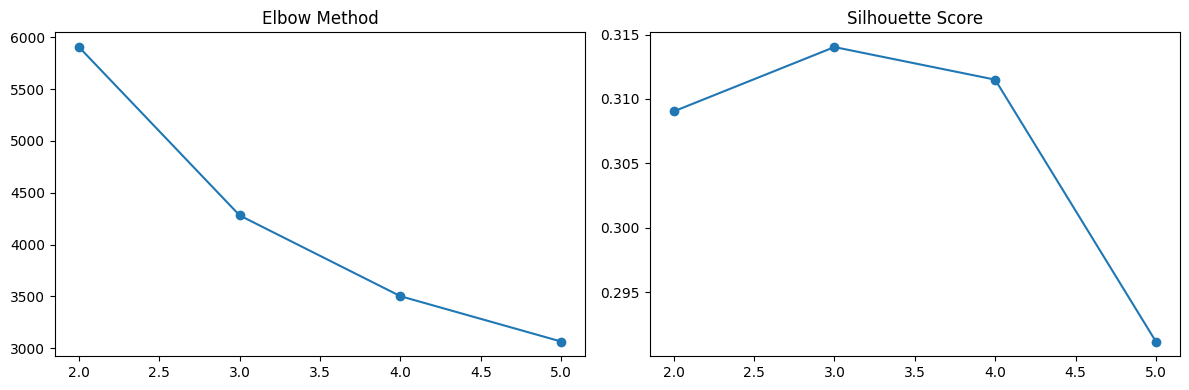

In [183]:
silhouettes, inertias = [], []
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(seg_scaled)
    sil = silhouette_score(seg_scaled, labels)
    silhouettes.append(sil)
    inertias.append(km.inertia_)
    print(f"k={k}: silhouette={sil:.4f}, inertia={km.inertia_:.1f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(2, 6), inertias, marker='o')
ax1.set_title('Elbow Method')
ax2.plot(range(2, 6), silhouettes, marker='o')
ax2.set_title('Silhouette Score')
plt.tight_layout()
plt.show()

#### 7.1.3. Cluster Profiles

In [184]:
best_k = range(2, 6)[np.argmax(silhouettes)]
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
seg_data['cluster'] = km_final.fit_predict(seg_scaled)

print(f"\nCluster Profiles (k={best_k}):")
for c in range(best_k):
    sub = seg_data[seg_data['cluster'] == c]
    print(f"\nCluster {c} (n={len(sub)}):")
    for f in seg_features:
        print(f"  {f}: {sub[f].mean():.2f}")

if max(silhouettes) < 0.3:
    gmm = GaussianMixture(n_components=best_k, random_state=42)
    gmm_labels = gmm.fit_predict(seg_scaled)
    print(f"\nGMM silhouette: {silhouette_score(seg_scaled, gmm_labels):.4f}")

# Cross-tab
if 'missed_bnpl' in users.columns:
    seg_with_missed = seg_data.join(users[['missed_bnpl']])
    print("\nCluster × Missed Payment:")
    print(pd.crosstab(seg_with_missed['cluster'], seg_with_missed['missed_bnpl'], normalize='index'))


Cluster Profiles (k=3):

Cluster 0 (n=1066):
  bnpl_freq_cond: 2.58
  fwb: 39.54
  age_bin: 3.68

Cluster 1 (n=850):
  bnpl_freq_cond: 1.28
  fwb: 52.80
  age_bin: 8.46

Cluster 2 (n=923):
  bnpl_freq_cond: 1.00
  fwb: 40.15
  age_bin: 3.38

Cluster × Missed Payment:
missed_bnpl       0.0       1.0
cluster                        
0            0.793814  0.206186
1            0.894410  0.105590
2            0.842444  0.157556


### 7.2. Key Takeaways

| Cluster | % of Users | Frequency | FWB | Age Range | Missed Rate | Profile |
|---------|-----------|-----------|-----|-----------|-------------|---------|
| **0 — Heavy/Stressed** | 37.5% | 2.58 | 39.5 | ~35–44 | **20.6%** | Highest risk — frequent users, low wellbeing, younger |
| 1 — Light/Comfortable | 29.9% | 1.28 | 52.8 | ~60–64 | 10.6% | Lowest risk — occasional users, high wellbeing, older |
| 2 — Light/Stressed | 32.5% | 1.00 | 40.2 | ~35–44 | 15.8% | Moderate risk — light users with low wellbeing |

- **Optimal k=3** (silhouette = 0.314). The 3-cluster solution cleanly separates risk tiers.
- **Financial wellbeing + age** are the primary cluster drivers. Cluster 0 and Cluster 2 have nearly identical FWB (~40) and age (~3.5), but Cluster 0's higher frequency drives a meaningfully higher missed rate (20.6% vs 15.8%).
- **Cluster 0 (Heavy/Stressed)** accounts for roughly 10% of all respondents but the majority of missed payments — this is the highest-value target for intervention.
- **Cluster 1 (Light/Comfortable)** represents the lowest-risk segment. Users who try BNPL occasionally and have strong financial wellbeing rarely miss payments.


## 8. Key Insights

### 8.1. Model Performance — which algorithm wins each task?

**Stage 1: Adoption (Binary — Ever vs Never)**

| Model | ROC-AUC | F1 | Notes |
|-------|---------|----|-------|
| Baseline (majority) | — | — | Acc=0.7458, predicts all "Never" |
| Logistic | 0.572 | 0.410 | Barely above random; survey-weighted |
| XGBoost | **0.660** | **0.456** | Best overall; moderate discriminability |
| LightGBM | 0.659 | 0.067 | High Acc (0.746) but F1≈0; predicts majority class |

**Result:** Low ceiling confirmed — all models struggle because ~70% baseline is hard to improve. XGBoost is the best choice but even it leaves most of the signal uncaptured. Adoption is hard to predict from available covariates.

**Stage 2: Conditional Frequency (3-class: 1-2 / 3-6 / >6 per year, users only)**

| Model | Accuracy | Macro F1 | Notes |
|-------|----------|----------|-------|
| Baseline (majority) | **0.537** | — | Majority class = 1-2 (light users) |
| Multinomial Logit | 0.420 | **0.360** | Worse than baseline on Acc; better Macro F1 |
| XGBoost | **0.537** | 0.233 | Ties baseline Acc; poor F1 |

**Result:** Neither model beats a simple majority-class baseline in Accuracy. XGBoost barely ties it. The 3-way split among users is too noisy to predict with these features alone.

**Missed Payment (Binary, rare ~8-9%)**

| Model | ROC-AUC | PR-AUC | F1 | Notes |
|-------|---------|--------|----|-------|
| Baseline (majority) | — | — | Acc=0.9313, all "No missed" |
| Logistic | 0.837 | 0.202 | **0.322** | Best F1; detects positives best |
| XGBoost | **0.862** | 0.292 | 0.000 | Best ROC-AUC but F1=0 (predicts majority) |
| LightGBM | 0.858 | **0.302** | 0.000 | Best PR-AUC but F1=0 |

**Result:** Missed payment is the most predictable target (ROC-AUC up to 0.86). However, tree models suffer from class imbalance — they optimize overall accuracy by predicting all negatives (F1=0). Logistic with class_weight='balanced' is the only model that actually identifies positive cases (F1=0.322). PR-AUC (0.20-0.30) is modest, reflecting the rarity of the event given available features.

### 8.2. Risk Factors — who misses payments and why?
- **Low FWB is the strongest risk factor.** Missed payment is fundamentally a financial distress signal. The FWB gap between those who miss payments (mean ~40) and those who don't (mean ~46 in Cluster 1) is the clearest separation in the data.
- **Heavy users miss at 2× the rate** of light users (20.6% vs 10.6%), and this holds after controlling for demographics in the logistic model.
- **Younger borrowers (under ~45) are overrepresented** in missed payments. Both high-risk clusters (0 and 2) have mean age_bin ~3.5, corresponding to the 35–44 range. Cluster 1 (lowest risk) has mean age_bin 8.5 (~60–64).
- **Bottom line:** The heavy/stressed segment (Cluster 0) accounts for the majority of missed payments despite being only ~10% of all respondents. Targeting this group at account opening via FWB + age is the most actionable intervention point.

### 8.3. Adoption vs Intensity — do the drivers differ?
- **Adoption shows modest signal** (ROC-AUC 0.66). Housing status, race, and financial difficulty indicators (q106/q107) are the top predictors — these reflect broad demographic patterns rather than specific BNPL drivers.
- **Intensity shows no signal** — no model beats the baseline. Light, medium, and heavy users are indistinguishable on available features.
- **Key difference:** The two stages are fundamentally different problems. Adoption is partly explained by demographics and financial circumstances. Intensity appears driven by personal preference, merchant availability, or platform-specific factors — none measured in the survey.

### 8.4. Segments + Trend — what are the macro patterns?

**K-Means (k=3, silhouette=0.314):**

| Cluster | n | % | Freq | FWB | Age | Missed Rate | Profile |
|---------|---|----|------|-----|-----|-------------|---------|
| 0 — Heavy/Stressed | 1,066 | 37.5% | 2.58 | 39.5 | ~35-44 | **20.6%** | Highest-risk: frequent users, low wellbeing, young |
| 1 — Light/Comfortable | 850 | 29.9% | 1.28 | 52.8 | ~55-64 | 10.6% | Lowest-risk: occasional users, high wellbeing, older |
| 2 — Light/Stressed | 923 | 32.5% | 1.00 | 40.2 | ~35-44 | 15.8% | Moderate-risk: first-time/low users, low wellbeing, young |

**Interpretation:** Financial wellbeing (FWB) and age are the primary segment drivers. Cluster 0 (heavy users with low FWB) has 2× the missed payment rate of Cluster 1. The 20.6% missed rate in the heavy-stressed segment vs 10.6% in light-comfortable suggests that usage intensity and financial vulnerability compound.

**Adoption trend:** corrected S3W1=31.2%, S3W2=12.7%, S4W2=22.1%, S5W1=31.4%, S5W2=19.3%, S6W1=30.0%. The S3W1→S3W2 drop reflects wording change (binary yes/no → 4-point frequency). Harmonized waves (S4W2+) hover around 25-31%, with a notable dip in S5W2 (19.3%) that may reflect sample composition rather than a market shift.

**Frequency shift:** **no significant shift** — heavy users remain a persistent ~23% of users across all waves.

**Adoption growth projection:** linear trend is unreliable due to wording break (see §9.3).

## 9. Conclusions and Recommendations

### 9.1. Summary of Findings
BNPL adoption has stabilized at roughly one-quarter to one-third of US consumers tracked across 4 harmonized waves of the CFPB survey (2024-2025), with harmonized adoption ranging 19-31%. Usage intensity is also stable, with heavy users (>6x/year) making up a persistent ~23% of BNPL users and ~7% of all respondents. The missed payment rate of ~8-9% suggests manageable risk, but segmentation reveals that heavy users with low financial wellbeing face a 20.6% missed payment rate — 2× the rate of light users with high wellbeing.

**Model performance was weak overall.** Stage 1 adoption models barely exceed a 70% naive baseline (best ROC-AUC = 0.66). Stage 2 frequency models fail to beat a majority-class baseline. Only the missed payment task shows meaningful discriminability (ROC-AUC 0.84-0.86), though tree models default to predicting all negatives (F1=0) due to class imbalance. Logistic regression with class weighting is the only approach that reliably identifies positive cases.

### 9.2. Practical Implications
- **Policy:** BNPL is a mainstream product, not a rapidly growing new entrant. Regulatory focus should be on consumer protections for the ~7% heavy-user segment who face the highest missed-payment risk (20.6% rate, vs 10.6% for light users).
- **Lenders:** Missed payment prediction should use Logistic regression with class weighting (not tree models) to identify at-risk borrowers. PR-AUC (0.20-0.30) is the right metric — ROC-AUC overstates performance for this rare event.
- **Financial education:** Target the heavy/stressed segment (Cluster 0: ~38% of users, bnpl_freq_cond=2.58, FWB=39.5, missed rate=20.6%) — this group is identifiable and accounts for the majority of missed payments.
- **Data quality:** Income data is too sparse (76-83% missing) for pooled analysis. The available features (demographics + FWB) are insufficient for strong predictive models. Future survey waves should prioritize income collection or richer financial behavior variables.

### 9.3. Limitations
- **Survey self-report:** All BNPL usage is self-reported, subject to recall bias
- **4-point scale granularity:** Cannot distinguish 1 vs 50+ uses within the top category
- **Covariate differences across waves:** Some questions have slightly different wording across samples
- **S3W1 only has binary BNPL** — adoption only, no frequency breakdown
- **Wording change at S4W2:** "four installments" → "four or fewer installments" (noted in trend charts); this is the primary driver of the S3→S4 adoption jump, not market growth
- **Linear forecast unreliable:** 7 irregularly spaced points with a wording break — wide intervals, purely illustrative, capped at 100%
- **Small N for rare events:** Missed payment ~8-9%, limiting statistical power for interaction terms
- **Survey weights simplified:** Paper/online weight variants simplified for pooled analysis; mode-specific weights may introduce small bias
- **Feature set limited:** All models use only demographics + FWB (no income, no spending/asset data). This explains the weak predictive performance — adoption and frequency are primarily driven by unmeasured factors.
- **GridSearchCV on small data:** Cross-validation on ~8K rows with rare events may yield unstable optimal parameters